<a href="https://colab.research.google.com/github/DariaChernykh4/lviv-food-marketplace-intelligence/blob/main/notebooks/02_market_analysis/03_restaurant_performance_analysis.ipynb%20" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Restaurant Performance Analysis**


### [**View Interactive Dashboard (Tableau Public)**](https://public.tableau.com/views/RestaurantPerfomanceOperations1/RestaurantOverview?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## **1. Introduction**

This project analyzes the operational and financial performance of an independent restaurant between January 2023 and December 2025.

The dataset combines transaction-level sales data, digital channel performance, category-level summaries and consolidated financial statements.

The objective of this analysis is to identify key revenue drivers, evaluate profitability, understand customer purchasing behavior and assess the contribution of different sales channels to overall business performance.

### Business Questions

This project aims to answer the following questions:

- How has restaurant revenue and demand evolved between 2023 and 2025?
- Which product categories are the main drivers of revenue?
- What customer ordering patterns can be identified?
- Which sales channels contribute most to restaurant revenue?
- How dependent is the restaurant on third-party delivery platforms?
- What are the main cost drivers affecting profitability?

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

from google.colab import drive, files

## **2. Data Loading**

In [2]:
# Mount Google Drive and navigate to the project folder

In [3]:
# Display and visualization settings

pd.options.display.float_format = "{:,.2f}".format

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

colors = [
    "#587032",
    "#f67227",
    "#e764a5",
    "#ffbcbb",
    "#f04639"
]

## **3. Dataset Structure**


***Dataset Description***

This dataset provides a multi-channel operational and financial view of a small independent restaurant covering the period from January 2023 to December 2025.

Unlike traditional restaurant datasets that focus on a single source, this collection integrates:

- transaction-level sales data;
- digital sales channels;
- delivery platform performance;
- category-level sales summaries;
- consolidated financial statements.

The data allows analysis of restaurant operations from both operational and financial perspectives.

### **3.1 Data Dictionary Overview**

In [4]:
df["file_name"].value_counts()

,count
file_name,
Anonymized_Restaurant_Sales_Data.csv,14
Public_EPOS_Category_Summary_2023_2025.csv,10
Public_Deliveroo_Category_Summary_2023_2025.csv,8
Public_EPOS_Annual_Category_Mix_2023_2025.csv,6
Public_Aggregator_Monthly_Revenue_FinancialYear.csv,6
Public_DigitalChannels_Monthly_Revenue_FinancialYear.csv,6
Public_Derived_Consolidated_PnL_2023_2025.csv,4


**Dataset Components**

The project contains seven interconnected datasets:

- **Sales Data** - Transaction-level sales records
- **Monthly Revenue** - Revenue by platform and month
- **Deliveroo Categories** - Category performance on Deliveroo
- **EPOS Category Summary** - Internal category-level sales performance
- **Annual Category Mix** - Category share by year
- **Digital Channels Revenue** - Revenue comparison across channels
- **Consolidated P&L** - Financial performance and profitability

### **3.2 Dataset Schema**

In [5]:
for file in df["file_name"].unique():
    print("\n", file)

    display(
        df[df["file_name"] == file][
            [
                "column_name",
                "data_type",
                "description",
                "example_value"
            ]
        ]
    )


 Anonymized_Restaurant_Sales_Data.csv


,column_name,data_type,description,example_value
0,OrderID,object,An anonymised order identifier used to group m...,RES_ORD_931.0
1,Date,object,Calendar date on which the order was placed.,03/01/2023
2,DayOfWeek,object,Day of the week derived from the order date.,Tuesday
3,Time,object,Time of day at which the order was placed (24-...,18:50
4,Category,object,Generalised menu category to which the ordered...,APETISERS
5,Line item name,object,Anonymised or generalised menu item name. Spec...,Chicken Suya
6,Quantity,int64,Number of units of the menu item ordered withi...,2
7,Price Per Item,float64,Unit price charged for a single item at the ti...,3.5
8,Gross Sales,float64,Total revenue generated by the line item befor...,7
9,Est. Cost,float64,Estimated cost of goods sold for the line item...,2.45



 Public_EPOS_Category_Summary_2023_2025.csv


,column_name,data_type,description,example_value
14,Category,object,High-level menu category representing groups o...,APPETISERS
15,Quantity,int64,Total number of items sold within the category...,920
16,Gross_Sales,float64,Total gross revenue generated by the category ...,5611.27
17,Net_Sales,float64,Net revenue for the category after discounts a...,5543.49
18,Discounts,float64,Total value of discounts applied to items with...,13.23
19,Tax_or_Fees,float64,Total tax or fee amounts associated with categ...,67.78
20,Cost_or_Other,float64,Cost-related or adjustment values reported at ...,3804
21,Sales_Channel,object,Sales channel identifier indicating the origin...,EPOS
22,Data_Level,object,Indicates the level of aggregation applied to ...,Period_Category_Summary
23,Data_Period,object,Descriptive label indicating the time coverage...,EPOS item/category summary (Jan 2023 - Dec 2025)



 Public_EPOS_Annual_Category_Mix_2023_2025.csv


...

,column_name,data_type,description,example_value
36,Financial_Year,object,UK financial year label for the record (AprMar).,2022-23
37,Month_Num,int64,Numeric month (112) for ordering and analysis.,1
38,Month,object,Month name corresponding to Month_Num.,January
39,Channel,object,"Sales channel identifier (e.g., Website, JustE...",Deliveroo
40,Revenue,float64,Total revenue attributed to the channel for th...,324.36
41,Revenue_Source,object,Indicates whether the revenue figure is observ...,Observed



 Public_Derived_Consolidated_PnL_2023_2025.csv


,column_name,data_type,description,example_value
42,Account Category,object,High-level financial grouping for the line ite...,Operating Revenue
43,Description,object,Specific line-item label within the account ca...,Direct Web Sales (Processor A)
44,Value (£),float64,Monetary value of the line item in GBP for the...,22878.25
45,Revenue %,object,Percentage of total consolidated revenue repre...,8.00%



 Public_Deliveroo_Category_Summary_2023_2025.csv


,column_name,data_type,description,example_value
46,Year,int64,"Calendar year of delivery, derived from the de...",2023
47,Month,object,"Month name of delivery, derived from the deliv...",August
48,Category,object,Generalised menu category for items sold via D...,Appetisers
49,Quantity,int64,Total number of items sold in the category for...,26
50,Gross_Revenue,float64,Total gross revenue received for items in the ...,126.5
51,Sales_Channel,object,Sales channel label identifying the platform s...,Deliveroo
52,Data_Level,object,Indicates the dataset granularity and aggregat...,Monthly_Category_Aggregate
53,Data_Period,object,Descriptive label indicating the coverage peri...,Jan 2023 - Dec 2025


## **4. Dataset Overview**

### **4.1. Dataset Dimensions**

In [6]:
# Dataset dimensions

datasets = {
    "sales": sales,
    "deliver_cat": deliver_cat,
    "pnl": pnl,
    "channels": channels,
}

for name, dataset in datasets.items():
    print(f"{name}: {dataset.shape}")

sales: (4385, 14)
deliver_cat: (235, 8)
pnl: (31, 4)
channels: (108, 6)


### **4.2. Main Dataset Overview**

In [7]:
# Main dataset overview

sales.info()
display(sales.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4385 entries, 0 to 4384
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         4385 non-null   object 
 1   Date            4385 non-null   object 
 2   DayOfWeek       4385 non-null   object 
 3   Time            4385 non-null   object 
 4   Category        4385 non-null   object 
 5   Line item name  4385 non-null   object 
 6   Quantity        4385 non-null   int64  
 7   Price Per Item  4385 non-null   float64
 8   Gross Sales     4385 non-null   float64
 9   Est. Cost       4385 non-null   float64
 10  Est. Profit     4385 non-null   float64
 11  OrderType       4385 non-null   object 
 12  Payment         4385 non-null   object 
 13  Cancelled       4385 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 479.7+ KB


,Quantity,Price Per Item,Gross Sales,Est. Cost,Est. Profit
count,"4,385.00","4,385.00","4,385.00","4,385.00","4,385.00"
mean,1.63,5.78,8.82,3.09,5.73
std,1.19,3.78,7.15,2.50,4.65
min,1.00,0.00,0.00,0.00,0.00
25%,1.00,2.50,3.50,1.22,2.28
50%,1.00,5.50,7.50,2.62,4.88
75%,2.00,8.00,10.00,3.50,6.50
max,20.00,40.00,64.50,22.57,41.93


**Main Dataset**

The primary dataset used in this analysis is the sales dataset.

It contains transaction-level records for menu items sold between 2023 and 2025.

Each observation includes information about:

- transaction date and time;
- product category;
- quantity sold;
- revenue generated;
- estimated cost and profit;
- order type;
- payment method;
- cancellation status.

In [8]:
# Column types

num_cols = sales.select_dtypes(include=np.number).columns
cat_cols = sales.select_dtypes(include="object").columns

print(f"Numeric columns ({len(num_cols)}): {list(num_cols)}")
print(f"Categorical columns ({len(cat_cols)}): {list(cat_cols)}")

Numeric columns (5): ['Quantity', 'Price Per Item', 'Gross Sales', 'Est. Cost', 'Est. Profit']
Categorical columns (9): ['OrderID', 'Date', 'DayOfWeek', 'Time', 'Category', 'Line item name', 'OrderType', 'Payment', 'Cancelled']


### **4.3. Analytical Framework**


The analysis will be conducted across four business dimensions:

1. Sales Performance
   - revenue trends
   - order volume
   - average order value

2. Product Performance
   - category contribution
   - top-selling products
   - profitability

3. Customer Behavior
   - order timing
   - payment preferences
   - order types

4. Channel Performance
   - website sales
   - delivery platforms
   - channel revenue contribution

### **4.4. Data Quality Assessment**

In [9]:
# Data quality checks

print("Missing values:")
print(sales.isna().sum())

print("\nDuplicate records:")
print(sales.duplicated().sum())

cancelled = sales["Cancelled"].value_counts()
cancelled_pct = sales["Cancelled"].value_counts(normalize=True).mul(100).round(2)

print("\nCancelled orders:")
print(cancelled)
print(cancelled_pct)

Missing values:
OrderID           0
Date              0
DayOfWeek         0
Time              0
Category          0
Line item name    0
Quantity          0
Price Per Item    0
Gross Sales       0
Est. Cost         0
Est. Profit       0
OrderType         0
Payment           0
Cancelled         0
dtype: int64

Duplicate records:
0

Cancelled orders:
Cancelled
No     4361
Yes      24
Name: count, dtype: int64
Cancelled
No    99.45
Yes    0.55
Name: proportion, dtype: float64


In [10]:
# Time coverage

sales["Date"].min(), sales["Date"].max()

('01/02/2023', '31/12/2025')

In [11]:
# Revenue validation

print(f"Gross sales: {sales['Gross Sales'].sum():,.2f}")
print(f"Est. Profit: {sales['Est. Profit'].sum():,.2f}")

sales[["Gross Sales", "Est. Cost", "Est. Profit"]].describe()

Gross sales: 38,678.75
Est. Profit: 25,147.42


,Gross Sales,Est. Cost,Est. Profit
count,"4,385.00","4,385.00","4,385.00"
mean,8.82,3.09,5.73
std,7.15,2.50,4.65
min,0.00,0.00,0.00
25%,3.50,1.22,2.28
50%,7.50,2.62,4.88
75%,10.00,3.50,6.50
max,64.50,22.57,41.93


**Data Quality Assessment Summary**

The sales dataset contains **4,385 transaction-level records** covering restaurant operations between **February 2023 and December 2025**.

No missing values or duplicate records were identified, indicating a high level of data completeness and consistency.

Only **24 records (0.55%) were marked as cancelled** orders, suggesting that cancellations have a negligible impact on overall sales performance.

Before currency conversion, the dataset generated total **gross sales of £38,678**.75 and an estimated profit of **£25,147.42** during the observed period.

Financial variables show no abnormal negative values, and the distribution of sales and profit values appears reasonable for transaction-level restaurant data.

Overall, the dataset is suitable for operational, financial and customer behavior analysis.

## **5. Data Preparation**



This section focuses on transforming the raw sales dataset into an analysis-ready format.

The preparation process includes:

- standardizing column names;
- converting date and time fields into appropriate formats;
- creating additional temporal features;
- standardizing financial metrics into Ukrainian Hryvnia (UAH);
- calculating profitability indicators.

These transformations enable consistent trend, seasonality and operational analysis throughout the project.

**Column Standardization**

Column names were standardized to snake_case format to improve readability and ensure consistency throughout the analysis.

In [12]:
# Column standardization

sales.columns = (
    sales.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "")
)

sales = sales.rename(columns={
    "orderid": "order_id",
    "dayofweek": "day_of_week",
    "ordertype": "order_type"
})

**Datetime Conversion**

Date and time variables were converted into appropriate datetime formats to support time-based analysis.

In [13]:
# Datetime conversion and time features

sales["date"] = pd.to_datetime(sales["date"], dayfirst=True)
sales["hour"] = pd.to_datetime(sales["time"], format="%H:%M").dt.hour

sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales["quarter"] = sales["date"].dt.quarter

**Currency Standardization**

To support future benchmarking against the Lviv restaurant marketplace, financial metrics were converted from GBP to UAH.

A fixed exchange rate of 59.6544 UAH per GBP was applied based on the official exchange rate published by the National Bank of Ukraine.

In [14]:
# Currency conversion

GBP_TO_UAH = 59.6544

sales["gross_sales_uah"] = sales["gross_sales"] * GBP_TO_UAH
sales["est_cost_uah"] = sales["est_cost"] * GBP_TO_UAH
sales["est_profit_uah"] = sales["est_profit"] * GBP_TO_UAH

**Revenue Validation**

The converted financial metrics were reviewed to verify overall revenue and profitability levels.

In [15]:
# Revenue validation after currency conversion

print(f"Total Revenue: {sales['gross_sales_uah'].sum():,.2f} UAH")
print(f"Total Profit: {sales['est_profit_uah'].sum():,.2f} UAH")

Total Revenue: 2,307,357.62 UAH
Total Profit: 1,500,154.25 UAH


**Zero-Value Transactions Review**

A small number of transactions with zero revenue were identified and investigated to determine whether they represent data quality issues or valid business events.

In [16]:
# Zero-value transactions

zero_sales = sales[sales["gross_sales"] == 0]

zero_sales[["order_id", "line_item_name", "cancelled"]]

,order_id,line_item_name,cancelled
469,RES_ORD_2204.0,Jolof,No
910,RES_ORD_2513.0,Jolof,No
1868,RES_ORD_3114.0,Jolof,No
2378,RES_ORD_3430.0,Jolof,No
2508,RES_ORD_3530.0,Jolof,No
3063,RES_ORD_4986.0,Jolof,No
3069,RES_ORD_4995.0,Jolof,No
3236,RES_ORD_5110.0,Jolof,No


In [17]:
sales.loc[sales["line_item_name"] == "Jolof", "line_item_name"].value_counts()

,count
line_item_name,
Jolof,53


**8 zero-value transactions** were identified.

All observations belong to the same menu item ("Jolof") and were not marked as cancelled orders.

Given their low frequency (less than 0.2% of all records), these transactions were retained in the dataset and treated as valid operational observations.

**Profit Margin Calculation**

Profit margin was calculated to evaluate the relationship between revenue and estimated profit at the transaction level.

In [18]:
# Profit margin

sales["profit_margin"] = np.where(
    sales["gross_sales_uah"] > 0,
    sales["est_profit_uah"] / sales["gross_sales_uah"] * 100,
    np.nan
)

sales["profit_margin"].describe()

,profit_margin
count,"4,377.00"
mean,65.02
std,0.07
min,64.80
25%,65.00
50%,65.00
75%,65.05
max,65.33


Profit margins remain highly consistent across transactions, averaging **approximately 65%**.

This suggests a relatively stable cost structure, meaning revenue trends are expected to closely mirror profit trends throughout the analysis.

In [19]:
# Final prepared dataset overview

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4385 entries, 0 to 4384
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         4385 non-null   object        
 1   date             4385 non-null   datetime64[ns]
 2   day_of_week      4385 non-null   object        
 3   time             4385 non-null   object        
 4   category         4385 non-null   object        
 5   line_item_name   4385 non-null   object        
 6   quantity         4385 non-null   int64         
 7   price_per_item   4385 non-null   float64       
 8   gross_sales      4385 non-null   float64       
 9   est_cost         4385 non-null   float64       
 10  est_profit       4385 non-null   float64       
 11  order_type       4385 non-null   object        
 12  payment          4385 non-null   object        
 13  cancelled        4385 non-null   object        
 14  hour             4385 non-null   int32  

**Data Preparation Summary**

The dataset was successfully transformed into an analysis-ready format through column standardization, datetime conversion, feature engineering and financial metric conversion.

Additional temporal and profitability features were created to support operational, financial and customer behavior analysis.

The resulting dataset contains 4,385 transaction-level observations and provides a solid foundation for exploratory data analysis.

## **6. Exploratory Data Analysis**

### **6.1 Executive Summary**

In [20]:
# Executive summary KPIs

total_revenue = sales["gross_sales_uah"].sum().round(2)
total_profit = sales["est_profit_uah"].sum().round(2)
total_orders = sales["order_id"].nunique()
total_items_sold = sales["quantity"].sum()

avg_order_value = sales.groupby("order_id")["gross_sales_uah"].sum().mean().round(2)
avg_items_per_order = sales.groupby("order_id")["quantity"].sum().mean().round(2)

orders_per_day = sales.groupby("date")["order_id"].nunique().mean().round(2)
revenue_per_day = sales.groupby("date")["gross_sales_uah"].sum().mean().round(2)

summary_data = {
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Items Sold",
        "Avg Order Value",
        "Avg Items per Order",
        "Orders per Day",
        "Revenue per Day"
    ],
    "Value": [
        f"{total_revenue:,.0f} UAH",
        f"{total_profit:,.0f} UAH",
        f"{total_orders:,}",
        f"{total_items_sold:,}",
        f"{avg_order_value:,.2f} UAH",
        f"{avg_items_per_order:.2f}",
        f"{orders_per_day:.2f}",
        f"{revenue_per_day:,.2f} UAH"
    ]
}

pd.DataFrame(summary_data).set_index("Metric")

,Value
Metric,
Total Revenue,"2,307,358 UAH"
Total Profit,"1,500,154 UAH"
Total Orders,"1,408"
Total Items Sold,"7,157"
Avg Order Value,"1,638.75 UAH"
Avg Items per Order,5.08
Orders per Day,2.12
Revenue per Day,"3,480.18 UAH"


**Executive Summary Findings**

Between 2023 and 2025, the restaurant generated **2.31 million UAH** in total revenue and **1.50 million UAH** in estimated profit.

During this period, the restaurant processed **1,408 orders** and sold **7,157 items**.

The average order value was **1,638.75 UAH**, while each order included approximately **5 items** on average. This suggests that customers usually purchase multiple menu items per transaction.

On an average operating day, the restaurant processed around **2 orders** and generated approximately **3,480 UAH** in revenue.

Overall, the KPI overview indicates a small-scale restaurant operation with a relatively high average order value and strong estimated profitability.

### **6.2. Revenue Trends**

**Annual revenue trend**

In [21]:
# Annual metrics

revenue_by_year = (
    sales.groupby("year", as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        orders=("order_id", "nunique"),
        items=("quantity", "sum")
    )
)

revenue_by_year["revenue_mln"] = revenue_by_year["revenue"] / 1_000_000
revenue_by_year["avg_order_value"] = revenue_by_year["revenue"] / revenue_by_year["orders"]
revenue_by_year["items_per_order"] = revenue_by_year["items"] / revenue_by_year["orders"]
revenue_by_year["yoy_change"] = revenue_by_year["revenue"].pct_change().mul(100)

revenue_by_year

,year,revenue,orders,items,revenue_mln,avg_order_value,items_per_order,yoy_change
0,2023,"1,139,473.61",733,3692,1.14,"1,554.53",5.04,NaN
1,2024,"704,041.23",433,2233,0.70,"1,625.96",5.16,-38.21
2,2025,"463,842.79",242,1232,0.46,"1,916.71",5.09,-34.12


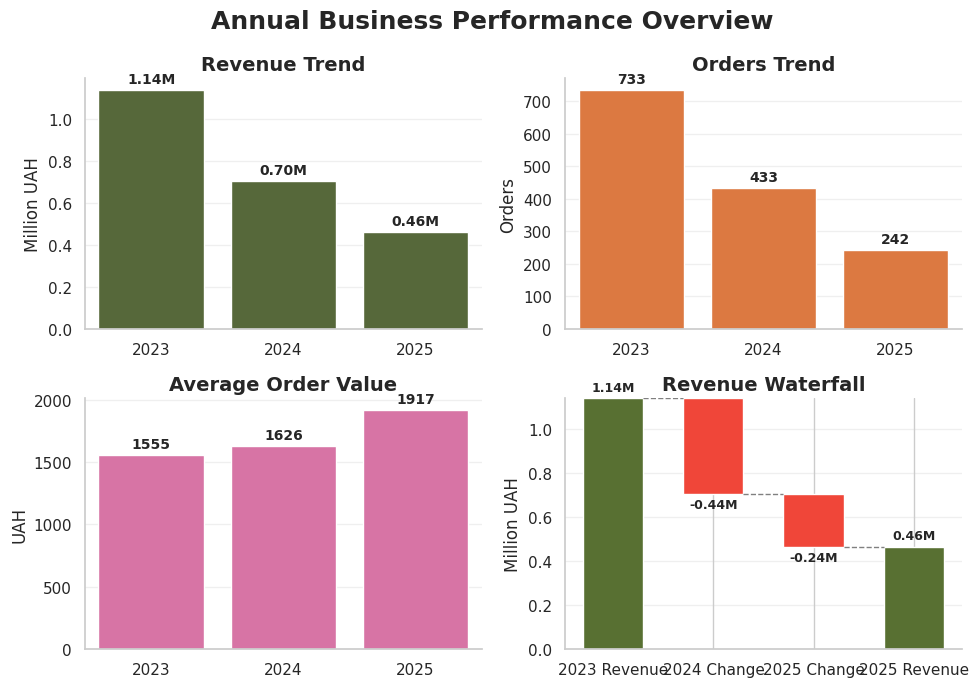

In [22]:
# Annual business performance dashboard

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

sns.barplot(data=revenue_by_year, x="year", y="revenue_mln", color=colors[0], ax=axes[0, 0])
axes[0, 0].set_title("Revenue Trend", fontsize=14, fontweight="bold")
axes[0, 0].set_ylabel("Million UAH")
axes[0, 0].set_xlabel("")

for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.2fM", padding=3, fontsize=10, fontweight="bold")

sns.barplot(data=revenue_by_year, x="year", y="orders", color=colors[1], ax=axes[0, 1])
axes[0, 1].set_title("Orders Trend", fontsize=14, fontweight="bold")
axes[0, 1].set_ylabel("Orders")
axes[0, 1].set_xlabel("")

for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt="%.0f", padding=3, fontsize=10, fontweight="bold")

sns.barplot(data=revenue_by_year, x="year", y="avg_order_value", color=colors[2], ax=axes[1, 0])
axes[1, 0].set_title("Average Order Value", fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel("UAH")
axes[1, 0].set_xlabel("")

for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt="%.0f", padding=3, fontsize=10, fontweight="bold")

# Revenue waterfall

waterfall_data = revenue_by_year[["year", "revenue_mln"]].copy()
waterfall_data["change"] = waterfall_data["revenue_mln"].diff()

waterfall_plot = pd.DataFrame({
    "label": ["2023 Revenue", "2024 Change", "2025 Change", "2025 Revenue"],
    "value": [
        waterfall_data.loc[0, "revenue_mln"],
        waterfall_data.loc[1, "change"],
        waterfall_data.loc[2, "change"],
        waterfall_data.loc[2, "revenue_mln"]
    ]
})

waterfall_plot["bottom"] = [
    0,
    waterfall_plot.loc[0, "value"],
    waterfall_plot.loc[0, "value"] + waterfall_plot.loc[1, "value"],
    0
]

waterfall_plot["color"] = [colors[0], colors[4], colors[4], colors[0]]

ax = axes[1, 1]

ax.bar(
    waterfall_plot["label"],
    waterfall_plot["value"],
    bottom=waterfall_plot["bottom"],
    color=waterfall_plot["color"],
    width=0.6
)

for i in range(len(waterfall_plot) - 1):
    current_top = waterfall_plot.loc[i, "bottom"] + waterfall_plot.loc[i, "value"]
    ax.plot(
        [i + 0.3, i + 1 - 0.3],
        [current_top, current_top],
        color="grey",
        linewidth=1,
        linestyle="--",
        zorder=3
    )

for i, row in waterfall_plot.iterrows():
    y = row["bottom"] + row["value"]
    label = f"{row['value']:+.2f}M" if i in [1, 2] else f"{row['value']:.2f}M"
    va = "bottom" if row["value"] >= 0 else "top"
    offset = 0.02 if row["value"] >= 0 else -0.02

    ax.text(i, y + offset, label, ha="center", va=va, fontsize=9, fontweight="bold")

ax.set_title("Revenue Waterfall", fontsize=14, fontweight="bold")
ax.set_ylabel("Million UAH")
ax.set_xlabel("")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Annual Business Performance Overview", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Annual Revenue Findings**

Between 2023 and 2025, the restaurant experienced a decline in business activity and overall performance.

Total revenue decreased from **1.14 million UAH** in 2023 to **704 thousand UAH** in 2024 and further to **464 thousand UAH** in 2025.

A similar trend can be seen in the number of orders. Order volume fell from **733 orders** in 2023 to **242 orders** in 2025, which represents a decline of approximately **67%** over the three-year period.

Despite the decrease in revenue and order volume, the **average order value increased steadily** from **1,555 UAH** in 2023 to **1,917 UAH** in 2025. This indicates that each individual order generated more revenue than in previous years.

Overall, the results suggest that the restaurant's main challenge is not pricing or basket size, but a significant decline in customer demand and order frequency. To support future growth, the business should focus on attracting new customers, increasing brand awareness, investing in marketing activities, and expanding its sales and delivery channels.

**Monthly Revenue and Orders Trends**

Annual metrics revealed a substantial decline in revenue and order volume between 2023 and 2025.

To better understand when this decline occurred, monthly trends are analyzed to identify seasonality patterns, periods of accelerated growth or decline, and changes in customer demand over time.

In [23]:
# Monthly metrics

monthly_metrics = (
    sales.groupby(["year", "month"], as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        orders=("order_id", "nunique")
    )
)

monthly_metrics["period"] = pd.to_datetime(monthly_metrics[["year", "month"]].assign(day=1))
monthly_metrics["revenue_k"] = monthly_metrics["revenue"] / 1_000

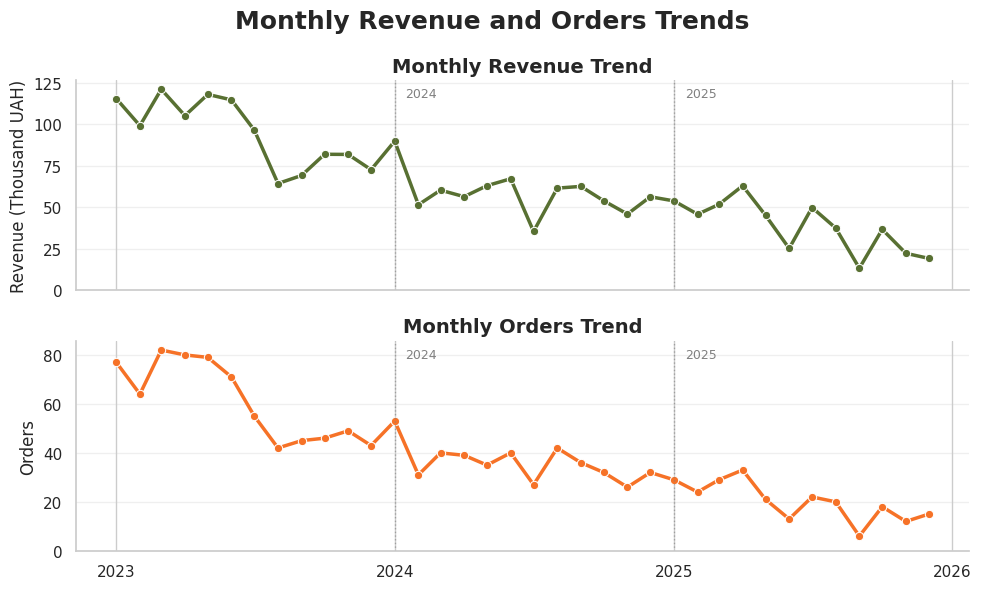

In [24]:
# Monthly revenue and orders dashboard

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

sns.lineplot(
    data=monthly_metrics,
    x="period",
    y="revenue_k",
    marker="o",
    linewidth=2.5,
    color=colors[0],
    ax=axes[0]
)

axes[0].set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Revenue (Thousand UAH)")
axes[0].set_xlabel("")
axes[0].set_ylim(0)

sns.lineplot(
    data=monthly_metrics,
    x="period",
    y="orders",
    marker="o",
    linewidth=2.5,
    color=colors[1],
    ax=axes[1]
)

axes[1].set_title("Monthly Orders Trend", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Orders")
axes[1].set_xlabel("")
axes[1].set_ylim(0)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Year separators
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)
    for year in [2024, 2025]:
        ax.axvline(
            pd.Timestamp(f"{year}-01-01"),
            color="grey", linewidth=1,
            linestyle=":", alpha=0.6
        )
        ax.text(
            pd.Timestamp(f"{year}-01-15"),
            ax.get_ylim()[1] * 0.92,
            str(year), fontsize=9, color="grey"
        )

plt.suptitle("Monthly Revenue and Orders Trends", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Monthly Trend Findings**

Monthly revenue and order volume show a clear downward trend over the analyzed period.

Both metrics move in a similar way, which means that revenue mainly depends on the number of customer orders.

The restaurant achieved its best results in the first half of **2023**, when monthly revenue was often above **100 thousand UAH** and the number of orders exceeded **70 per month**.

After mid-2023, both revenue and orders started to decrease. By **2025**, monthly revenue was usually below **60 thousand UAH**, while the number of orders often remained below **30 per month**.

The data does not show a strong seasonal pattern. Instead, it suggests a long-term decline in customer demand and order volume.

### **6.3. Menu Overview**

The restaurant specializes in traditional West African cuisine, with a strong focus on Nigerian dishes. The menu combines soups, rice-based meals, side dishes, snacks, beverages, and family-sized meal packages.

Before analyzing sales performance, it is useful to understand the structure of the menu and the number of products available in each category.

In [25]:
# Product portfolio by category

category_portfolio = (
    sales.groupby("category")["line_item_name"]
    .nunique()
    .reset_index(name="products_count")
    .sort_values("products_count", ascending=False)
)

category_portfolio

,category,products_count
2,EXTRAS,18
0,APETISERS,13
4,MAIN COURSES,8
1,DRINKS,7
6,SOUPS,7
5,Restaurant DEALS,6
7,SPECIAL ORDERS,3
3,Friday Specials,1


**Menu Structure**

The menu contains **63 unique products** distributed across **8 categories** (62 unique dishes, since one item - Beef Suya - appears in two categories).

The largest category is **EXTRAS**, which includes 18 products such as side dishes, stews, and additional items that are commonly ordered together with main meals. **APETISERS** is the second-largest category with 13 products, while **MAIN COURSES** and **SOUPS** contain 8 and 7 products respectively.

Some categories are highly specialized. For example, **Friday Specials** contains only one product, while **SPECIAL ORDERS** includes three niche items available on request.

The distribution of products suggests that the restaurant combines a relatively small number of core dishes with a wider range of supporting items that help increase customer choice and basket size.

In [26]:
# Product list by category

category_products = (
    sales.groupby("category")["line_item_name"]
    .agg(
        products_count="nunique",
        products=lambda x: sorted(x.unique())
    )
    .reset_index()
)

for _, row in category_products.iterrows():
    print(f"\n{row['category']} ({row['products_count']} products)")

    for product in row["products"]:
        print(f"• {product}")


APETISERS (13 products)
• Assorted Meat Pepper Soup
• Asun goat meat
• Beef Suya
• Buns
• Chicken Suya
• Chin Chin
• Fried Yam
• Goat Meat Peppersoup
• Meat Pie
• Nkwobi
• PEPPERED TURKEY
• Patty
• Plantain Chips

DRINKS (7 products)
• African Coke
• African Fanta
• Bottle Water
• Coke 330ml
• Malta Guinness
• Maltina
• Palm Wine

EXTRAS (18 products)
• Amala (Dried Yam Flour)
• Assorted Meat
• Assorted Meat Stew
• Ayamase Sauce
• Beef Stew
• Boiled Rice
• Chicken Stew
• Coleslaw
• Extra Stew
• Fried Fish
• Fried Plantain - Dodo
• Gari (Dried Cassava Flour)
• Moi Moi - Beans Pudding
• Plain Fried Rice
• Plain Jolof
• Pounded Yam
• Semolina (Maize Flour)
• Stewed Fried Fish

Friday Specials (1 products)
• Beef Suya

MAIN COURSES (8 products)
• Boiled Rice with Designer Stew - Ayamase
• Fried Rice
• Jolof
• Jolof with Beef
• Jolof with Chicken
• Jolof with Curry Goat
• Jolof with Fish
• Sphagetti Meatballs

Restaurant DEALS (6 products)
• Fried Rice (Sharing Pack Plain)
• Jolof Sharing 

**Main Menu Categories**

- **SOUPS** include traditional Nigerian soups such as Egusi, Efo Riro, Ogbono, Oha, and Okro. These dishes are typically served with swallow products such as pounded yam, semolina, gari, or amala.

- **MAIN COURSES** consist mainly of rice-based meals, including Jolof Rice and its variations served with chicken, fish, beef, or curry goat.

- **EXTRAS** contain side dishes and add-ons such as pounded yam, boiled rice, fried plantain, stews, assorted meats, and fish.

- **APETISERS** include snacks and starter dishes such as suya, pepper soups, meat pies, patties, buns, and plantain chips.

- **DRINKS** include both international soft drinks and traditional African beverages such as Palm Wine, Malta Guinness, and Maltina.

- **Restaurant DEALS** contain sharing packs and pre-order family meals designed for larger groups.

- **SPECIAL ORDERS** include niche menu items such as grilled tilapia and bean-based dishes.

- **Friday Specials** represent limited-time promotional menu items available on selected days.

#### **Key Traditional Dishes**

To better understand the analysis, it is useful to become familiar with several traditional Nigerian dishes that appear throughout the dataset.

**SOUPS**
- **Egusi Soup** - a rich soup made from ground melon seeds, vegetables, and traditional spices. It is one of the most popular dishes in Nigerian cuisine.
- **Efo Riro** - a spinach-based stew prepared with peppers, vegetables, and meat or fish.
- **Ogbono Soup** - a thick soup made from wild mango seeds (ogbono), known for its unique texture.
- **Oha Soup** - a traditional soup prepared with oha leaves, popular in eastern Nigeria.
- **Okro Soup** - a soup made from okra, often served with swallow side dishes.
- **Pepper Soup** - a spicy broth made with meat or fish, commonly served as a starter or light meal.

**MAIN COURSES**
- **Jolof Rice** - a famous West African rice dish cooked with tomatoes, peppers, onions, and spices.
- **Jolof with Chicken, Fish, Beef, or Curry Goat** - variations of Jolof Rice served with different protein options.
- **Fried Rice** - a popular rice dish prepared with vegetables and seasonings.

**EXTRAS & SIDE DISHES**
- **Pounded Yam** - a smooth dough-like side dish made from yam and traditionally served with soups.
- **Amala** - a swallow dish made from yam flour or cassava flour, commonly eaten with soups.
- **Gari** - a side dish made from fermented cassava and typically served with traditional soups.
- **Semolina** - a swallow side dish made from wheat semolina.
- **Moi Moi** - a steamed bean pudding prepared from blended beans and spices.
- **Plantain** - fried sweet plantain, commonly served as a side dish.
- **Ayamase Sauce** - a spicy green pepper sauce traditionally served with rice dishes.

**APETISERS**
- **Suya** - spicy grilled meat seasoned with traditional West African spices. One of the most popular street foods in the region.
- **Meat Pie** - a baked pastry filled with minced meat and vegetables.
- **Patty** - a savory pastry filled with meat or vegetables.
- **Chin Chin** - a crunchy fried snack made from sweet dough.
- **Buns** - deep-fried dough snacks commonly sold as street food.

**DRINKS**
- **Palm Wine** - a traditional African fermented beverage made from palm tree sap.
- **Malta Guinness** and **Maltina** - popular non-alcoholic malt drinks widely consumed across West Africa.

### **6.4. Category Performance Analysis**

In [27]:
# Category metrics

category_metrics = (
    sales.groupby("category", as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_metrics["revenue_share"] = (
    category_metrics["revenue"] / category_metrics["revenue"].sum() * 100
).round(2)

top3_categories = (
    category_metrics
    .sort_values("revenue", ascending=False)
    .head(3)["category"]
    .tolist()
)

category_metrics

,category,revenue,orders,quantity,revenue_share
2,EXTRAS,"768,766.25",1244,3530,33.32
6,SOUPS,"586,969.47",637,1156,25.44
4,MAIN COURSES,"501,365.40",733,1052,21.73
0,APETISERS,"288,622.90",617,1028,12.51
5,Restaurant DEALS,"77,341.93",45,47,3.35
7,SPECIAL ORDERS,"42,563.41",59,73,1.84
1,DRINKS,"34,241.63",206,257,1.48
3,Friday Specials,"7,486.63",12,14,0.32


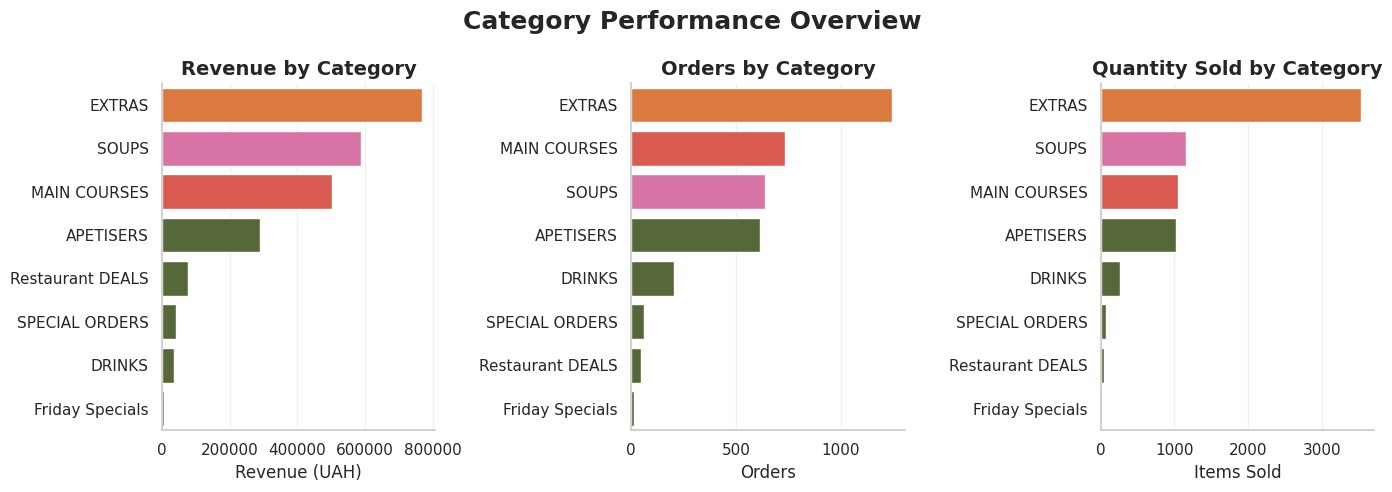

In [28]:
# Category performance dashboard

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

plots = [
    ("revenue", "Revenue by Category", "Revenue (UAH)"),
    ("orders", "Orders by Category", "Orders"),
    ("quantity", "Quantity Sold by Category", "Items Sold")
]

for ax, (metric, title, xlabel) in zip(axes, plots):
    data = category_metrics.sort_values(metric, ascending=False)

    palette = {
        category: (
            colors[1] if category == top3_categories[0]
            else colors[2] if category == top3_categories[1]
            else colors[4] if category == top3_categories[2]
            else colors[0]
        )
        for category in data["category"]
    }

    sns.barplot(
        data=data,
        x=metric,
        y="category",
        hue="category",
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Category Performance Overview", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
# Average revenue per order by category

category_metrics["avg_revenue_per_order"] = (
    category_metrics["revenue"] / category_metrics["orders"]
).round(0)

category_metrics[
    ["category", "revenue_share", "avg_revenue_per_order"]
].sort_values("revenue_share", ascending=False)

,category,revenue_share,avg_revenue_per_order
2,EXTRAS,33.32,618.00
6,SOUPS,25.44,921.00
4,MAIN COURSES,21.73,684.00
0,APETISERS,12.51,468.00
5,Restaurant DEALS,3.35,"1,719.00"
7,SPECIAL ORDERS,1.84,721.00
1,DRINKS,1.48,166.00
3,Friday Specials,0.32,624.00


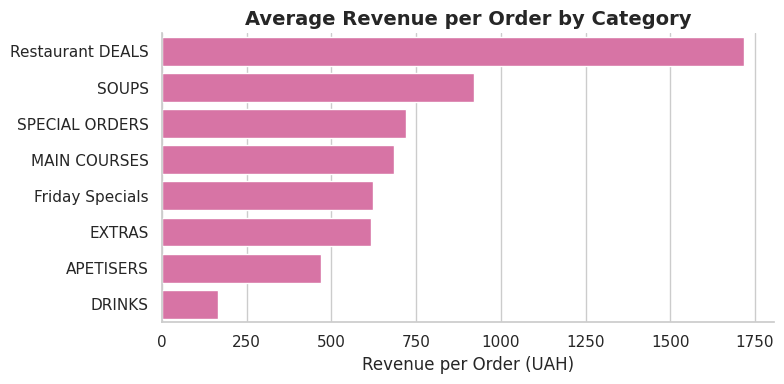

In [30]:
# Average revenue per order chart

data = category_metrics.sort_values("avg_revenue_per_order", ascending=False)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=data,
    x="avg_revenue_per_order",
    y="category",
    color=colors[2]
)

plt.title("Average Revenue per Order by Category", fontsize=14, fontweight="bold")
plt.xlabel("Revenue per Order (UAH)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

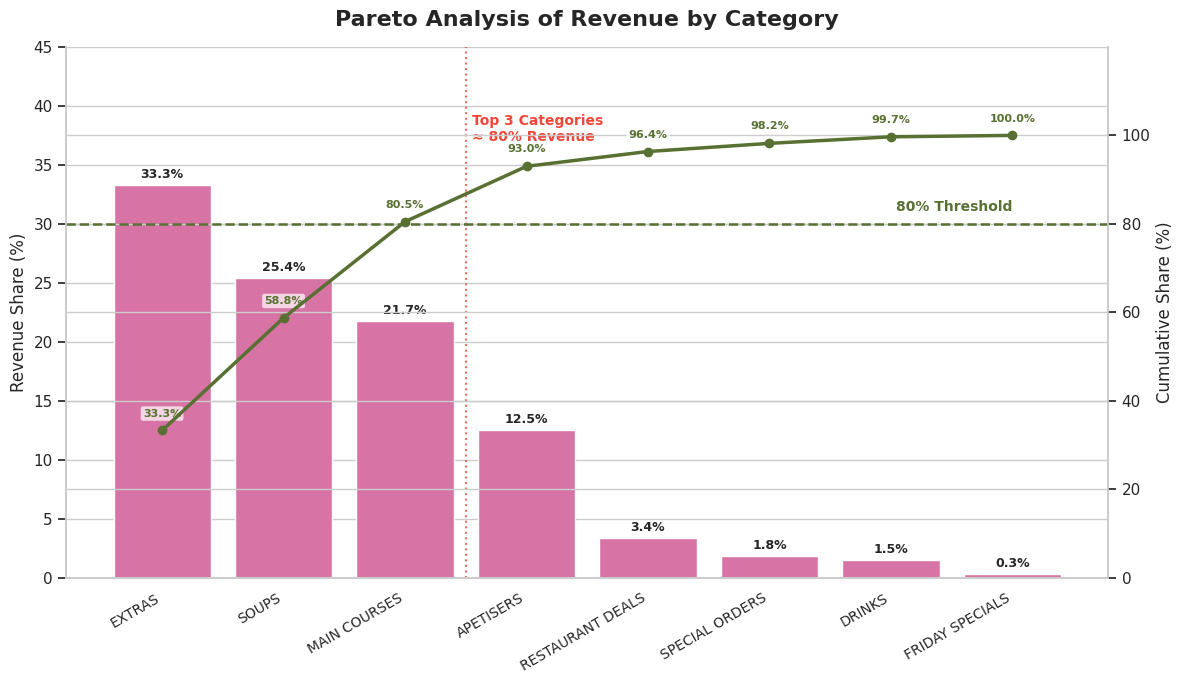

In [31]:
# Pareto analysis by category

pareto = category_metrics.sort_values("revenue_share", ascending=False).copy()
pareto["cum_share"] = pareto["revenue_share"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(data=pareto, x="category", y="revenue_share", color=colors[2], ax=ax1)

ax1.set_ylabel("Revenue Share (%)", fontsize=12)
ax1.set_xlabel("")
ax1.set_ylim(0, 45)

ax1.axvline(x=2.5, color=colors[4], linestyle=":", alpha=0.8)
ax1.text(2.55, 37, "Top 3 Categories\n≈ 80% Revenue", fontsize=10, fontweight="bold", color=colors[4])

for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9, fontweight="bold")

ax1.set_xticks(range(len(pareto)))
ax1.set_xticklabels(
    [category.upper() for category in pareto["category"]],
    rotation=30,
    ha="right",
    fontsize=10
)

ax2 = ax1.twinx()

ax2.plot(
    range(len(pareto)),
    pareto["cum_share"],
    marker="o",
    markersize=6,
    linewidth=2.5,
    color=colors[0],
    zorder=5
)

for i, value in enumerate(pareto["cum_share"]):
    ax2.annotate(
        f"{value:.1f}%",
        xy=(i, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=colors[0],
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none")
    )

ax2.set_ylabel("Cumulative Share (%)", fontsize=12)
ax2.set_ylim(0, 120)
ax2.set_yticks(range(0, 101, 20))

ax2.axhline(y=80, color=colors[0], linestyle="--", linewidth=1.8)
ax2.text(len(pareto) - 1, 83, "80% Threshold", color=colors[0], ha="right", fontsize=10, fontweight="bold")

plt.title("Pareto Analysis of Revenue by Category", fontsize=16, fontweight="bold", pad=15)

sns.despine(left=False, right=False)
plt.tight_layout()
plt.show()

**Category Performance Findings**

The top three categories - **EXTRAS**, **SOUPS**, and **MAIN COURSES** - generate around **80% of total revenue**. This means that the restaurant's performance depends heavily on a few key menu categories, while the remaining categories contribute only a small share of sales.

- **EXTRAS** is the largest category, generating **33.3% of total revenue**. It also has the highest number of orders and items sold. However, its average revenue per order is lower than that of SOUPS and MAIN COURSES, which suggests that its strong performance is mainly driven by a high number of orders rather than a high order value.

- **SOUPS** has the highest average revenue per order among the main categories, reaching **921 UAH per order**. This may indicate that customers who order soups tend to spend more or add more items to their orders.

- **Restaurant DEALS** has the **highest average revenue per order at 1,719 UAH**, but its contribution to total revenue remains relatively small due to a low number of orders. If demand increases, this category could become an additional source of revenue growth.

### **6.5. Product Perfomance Analysis**

In [32]:
# Product metrics by category

product_metrics = (
    sales.groupby(["category", "line_item_name"], as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        profit=("est_profit_uah", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
)

product_metrics["category_revenue"] = (
    product_metrics.groupby("category")["revenue"].transform("sum")
)

product_metrics["revenue_share_in_category"] = (
    product_metrics["revenue"] / product_metrics["category_revenue"] * 100
)

product_metrics["category_orders"] = (
    product_metrics.groupby("category")["orders"].transform("sum")
)

product_metrics["orders_share_in_category"] = (
    product_metrics["orders"] / product_metrics["category_orders"] * 100
)

In [33]:
# Top 3 products by revenue within each category

top3_revenue = (
    product_metrics
    .sort_values(["category", "revenue"], ascending=[True, False])
    .groupby("category")
    .head(3)
)

top3_revenue[
    ["category", "line_item_name", "revenue", "revenue_share_in_category"]
]

,category,line_item_name,revenue,revenue_share_in_category
0,APETISERS,Assorted Meat Pepper Soup,"112,836.30",39.09
4,APETISERS,Chicken Suya,"21,803.68",7.55
3,APETISERS,Buns,"21,475.58",7.44
14,DRINKS,African Fanta,"10,051.77",29.36
17,DRINKS,Malta Guinness,"7,337.49",21.43
18,DRINKS,Maltina,"7,307.66",21.34
34,EXTRAS,Plain Jolof,"150,120.30",19.53
23,EXTRAS,Ayamase Sauce,"108,630.66",14.13
35,EXTRAS,Pounded Yam,"101,412.48",13.19
38,Friday Specials,Beef Suya,"7,486.63",100.00


In [34]:
# Top 3 products by order volume within each category

top3_orders = (
    product_metrics
    .sort_values(["category", "orders"], ascending=[True, False])
    .groupby("category")
    .head(3)
)

top3_orders[
    ["category", "line_item_name", "orders", "orders_share_in_category"]
]

,category,line_item_name,orders,orders_share_in_category
0,APETISERS,Assorted Meat Pepper Soup,180,25.75
4,APETISERS,Chicken Suya,76,10.87
11,APETISERS,Patty,74,10.59
18,DRINKS,Maltina,54,25.71
17,DRINKS,Malta Guinness,50,23.81
14,DRINKS,African Fanta,40,19.05
35,EXTRAS,Pounded Yam,268,14.28
30,EXTRAS,Fried Plantain - Dodo,248,13.21
32,EXTRAS,Moi Moi - Beans Pudding,220,11.72
38,Friday Specials,Beef Suya,12,100.00


In [35]:
# Product concentration metrics

revenue_concentration = (
    top3_revenue.groupby("category")["revenue_share_in_category"]
    .sum()
    .reset_index(name="top3_revenue_share")
    .sort_values("top3_revenue_share", ascending=False)
)

orders_concentration = (
    top3_orders.groupby("category")["orders_share_in_category"]
    .sum()
    .reset_index(name="top3_orders_share")
    .sort_values("top3_orders_share", ascending=False)
)

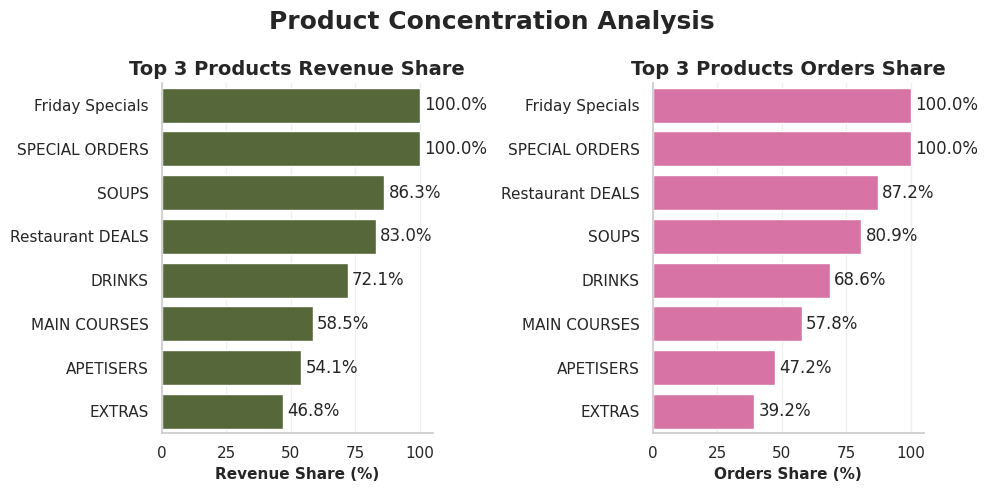

In [36]:
# Product concentration dashboard

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(
    data=revenue_concentration,
    x="top3_revenue_share",
    y="category",
    color=colors[0],
    ax=axes[0]
)

axes[0].set_title("Top 3 Products Revenue Share", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Revenue Share (%)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)

sns.barplot(
    data=orders_concentration,
    x="top3_orders_share",
    y="category",
    color=colors[2],
    ax=axes[1]
)

axes[1].set_title("Top 3 Products Orders Share", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Orders Share (%)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Product Concentration Analysis", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
# Category leaders from top-3 tables

revenue_leaders = top3_revenue.groupby("category").head(1)
orders_leaders = top3_orders.groupby("category").head(1)

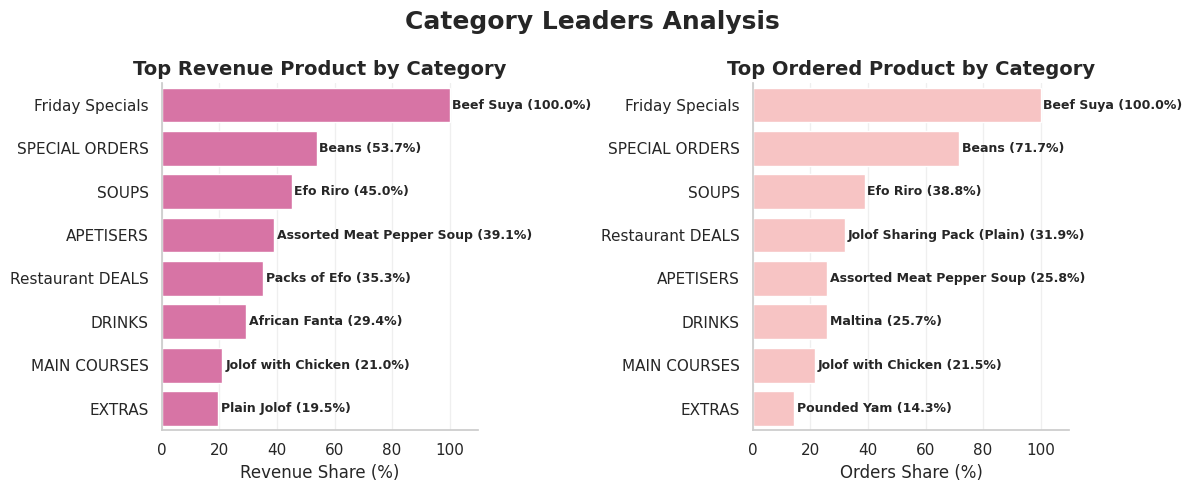

In [38]:
# Category leaders dashboard

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_revenue = revenue_leaders.sort_values("revenue_share_in_category", ascending=False)

sns.barplot(
    data=data_revenue,
    x="revenue_share_in_category",
    y="category",
    color=colors[2],
    ax=axes[0]
)

axes[0].set_title("Top Revenue Product by Category", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Revenue Share (%)")
axes[0].set_ylabel("")

for i, row in enumerate(data_revenue.itertuples()):
    axes[0].text(
        row.revenue_share_in_category + 1,
        i,
        f"{row.line_item_name} ({row.revenue_share_in_category:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

data_orders = orders_leaders.sort_values("orders_share_in_category", ascending=False)

sns.barplot(
    data=data_orders,
    x="orders_share_in_category",
    y="category",
    color=colors[3],
    ax=axes[1]
)

axes[1].set_title("Top Ordered Product by Category", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Orders Share (%)")
axes[1].set_ylabel("")

for i, row in enumerate(data_orders.itertuples()):
    axes[1].text(
        row.orders_share_in_category + 1,
        i,
        f"{row.line_item_name} ({row.orders_share_in_category:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

for ax in axes:
    ax.set_xlim(0, 110)
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Category Leaders Analysis", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Revenue and Demand Concentration Analysis**

The analysis shows that product performance varies significantly across categories. While some categories rely on a small number of products, others demonstrate a more balanced distribution of demand and revenue.

The highest concentration can be observed in **Friday Specials** and **SPECIAL ORDERS**. However, this result is largely explained by the limited number of products available in these categories. Friday Specials contains only **1 product**, while SPECIAL ORDERS includes only **3 products**, making high concentration expected rather than unusual.

Among the larger categories, **SOUPS** demonstrates the strongest concentration. The top three products generate approximately **86% of category revenue** and **81% of all orders**. In particular, **Efo Riro** alone accounts for **45% of category revenue** and nearly **39% of category orders**, making it the most important product within the category.

A similar pattern can be observed in **Restaurant DEALS**, where the top three products generate more than **80% of both revenue and orders**. Since the category contains only six products, customer demand is concentrated around a relatively small number of meal packages.

In contrast, **EXTRAS** shows the most diversified product portfolio. Despite containing **18 products**, the top three items contribute only **47% of revenue** and **39% of orders**. This indicates that customer demand is distributed across a wide range of products rather than concentrated around a few bestsellers.

Comparing revenue leaders and order leaders reveals that the most frequently ordered product is not always the largest contributor to revenue. For example, in **EXTRAS**, customers most often purchase **Pounded Yam**, while **Plain Jolof** generates the highest revenue. Similar differences can be observed in **DRINKS** and **Restaurant DEALS**.

Interestingly, categories such as **SOUPS**, **MAIN COURSES**, and **APETISERS** have the same products leading both revenue and order rankings. This suggests that the most popular products in these categories are also the primary drivers of revenue.

Overall, the results indicate that customer demand is highly concentrated in a few key products within several categories, particularly SOUPS and Restaurant DEALS. At the same time, categories such as EXTRAS benefit from a broader and more balanced product mix, reducing their dependence on individual menu items.

### **6.6. Customer & Order Analysis**

**Order Value and Basket Size**


In [39]:
# Order-level metrics

order_metrics = (
    sales.groupby("order_id", as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        items=("quantity", "sum"),
        date=("date", "min"),
        day_of_week=("day_of_week", "first"),
        hour=("hour", "first"),
        order_type=("order_type", "first"),
        payment=("payment", "first")
    )
)

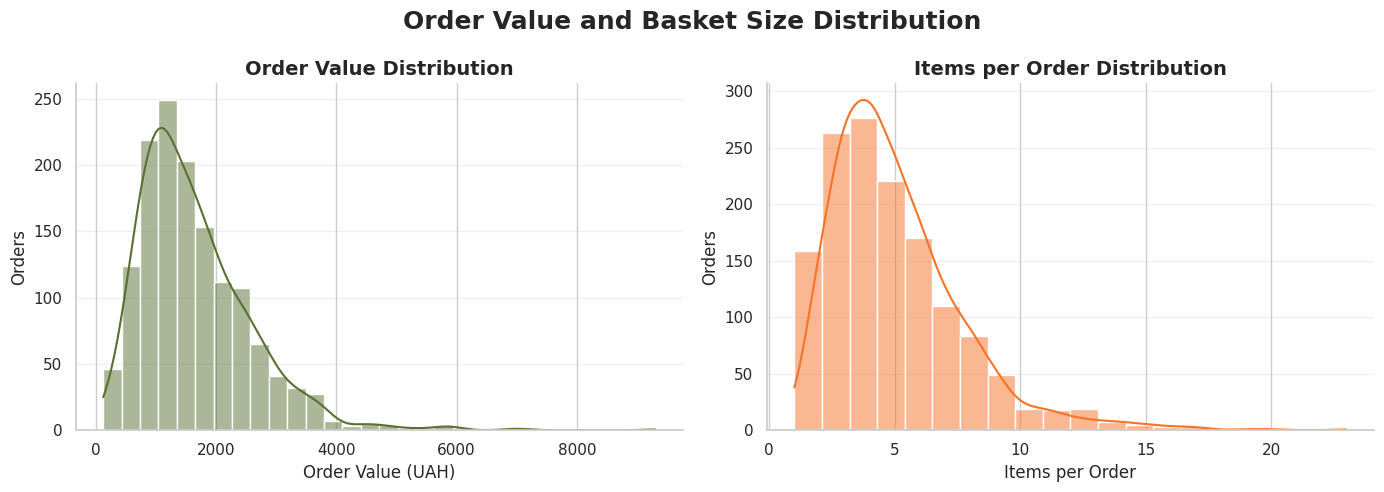

In [40]:
# Order value and items per order distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=order_metrics,
    x="revenue",
    bins=30,
    color=colors[0],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Order Value Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Order Value (UAH)")
axes[0].set_ylabel("Orders")

sns.histplot(
    data=order_metrics,
    x="items",
    bins=20,
    color=colors[1],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Items per Order Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Items per Order")
axes[1].set_ylabel("Orders")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Order Value and Basket Size Distribution", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
order_metrics[["revenue", "items"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
revenue,"1,408.00","1,638.75",938.10,119.31,984.30,"1,431.71","2,095.36","9,306.09"
items,"1,408.00",5.08,2.63,1.00,3.00,5.00,6.00,23.00


**Order Value and Basket Size Findings**

The average order value is **1,639 UAH**, while the median is **1,432 UAH**. This indicates that a small number of large orders increase the overall average.

Customers typically purchase **5 items per order**, and most orders contain **3-6 items**.

Most transactions fall between **984 UAH and 2,095 UAH**, showing that the restaurant mainly relies on regular medium-sized orders rather than a few very large purchases.

**Order Type Performance**

In [42]:
# Order type metrics

order_type_metrics = (
    order_metrics.groupby("order_type", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
        avg_items_per_order=("items", "mean")
    )
    .sort_values("revenue", ascending=False)
)

order_type_metrics

,order_type,orders,revenue,avg_order_value,avg_items_per_order
1,Delivery,1064,"1,683,238.38","1,581.99",4.98
0,Collection,344,"624,119.25","1,814.30",5.42


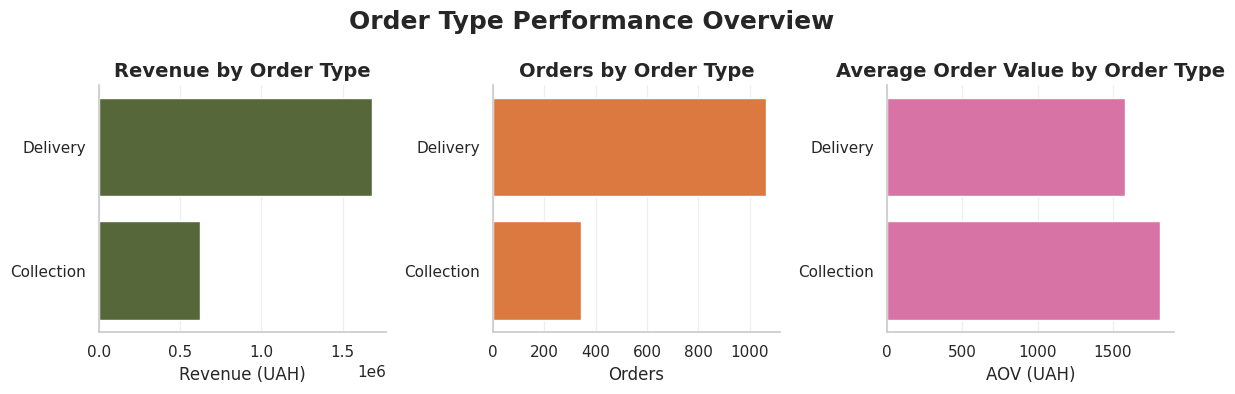

In [43]:
# Order type dashboard

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plots = [
    ("revenue", "Revenue by Order Type", "Revenue (UAH)", colors[0]),
    ("orders", "Orders by Order Type", "Orders", colors[1]),
    ("avg_order_value", "Average Order Value by Order Type", "AOV (UAH)", colors[2])
]

for ax, (metric, title, xlabel, color) in zip(axes, plots):
    sns.barplot(
        data=order_type_metrics,
        x=metric,
        y="order_type",
        color=color,
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Order Type Performance Overview", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Order Type Performance Findings**

**Delivery** is the main sales channel, generating **1.68 million UAH** in revenue and accounting for **1,064 orders**, which is about 76% of all orders.

**Collection** contributes a smaller share of total revenue (**624 thousand UAH**) and order volume (**344 orders**), but customers spend more per transaction. The average order value for Collection is **1,814 UAH**, compared to **1,582 UAH** for Delivery.

Customers also purchase slightly more items when using Collection (**5.4 items per order**) than Delivery (**5.0 items per order**).

Overall, restaurant revenue is heavily dependent on Delivery orders, while Collection customers tend to place larger and higher-value orders.

**Payment Method**


In [44]:
# Payment method metrics

payment_metrics = (
    order_metrics.groupby("payment", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
    .sort_values("orders", ascending=False)
)

payment_metrics

,payment,orders,revenue,avg_order_value
0,Card,1408,"2,307,357.62","1,638.75"


**Payment Method Findings**

All transactions in the dataset were paid by **Card**. As a result, no comparison between payment methods can be performed.

This may indicate that the restaurant primarily operates through online ordering platforms where card payments are the standard payment option.

### **6.7. Operational Analysis**

**Weekday Performance**

In [45]:
# Orders and revenue by weekday

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_metrics = (
    order_metrics.groupby("day_of_week", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
)

weekday_metrics["day_of_week"] = pd.Categorical(
    weekday_metrics["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_metrics = weekday_metrics.sort_values("day_of_week")

weekday_metrics

,day_of_week,orders,revenue,avg_order_value
1,Monday,203,"330,395.89","1,627.57"
4,Tuesday,192,"283,746.15","1,477.84"
5,Wednesday,209,"336,361.33","1,609.38"
3,Thursday,213,"361,028.43","1,694.97"
0,Friday,248,"401,548.68","1,619.15"
2,Saturday,343,"594,277.13","1,732.59"


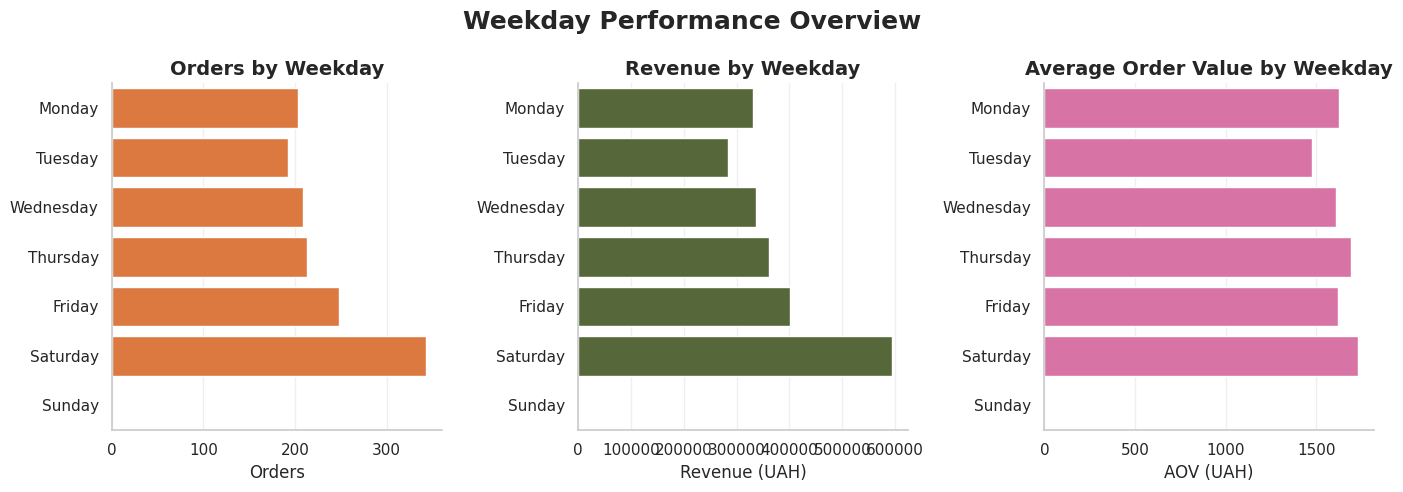

In [46]:
# Weekday performance dashboard

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

plots = [
    ("orders", "Orders by Weekday", "Orders", colors[1]),
    ("revenue", "Revenue by Weekday", "Revenue (UAH)", colors[0]),
    ("avg_order_value", "Average Order Value by Weekday", "AOV (UAH)", colors[2])
]

for ax, (metric, title, xlabel, color) in zip(axes, plots):
    sns.barplot(
        data=weekday_metrics,
        x=metric,
        y="day_of_week",
        color=color,
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Weekday Performance Overview", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Weekday Performance Findings**

Customer activity is relatively stable throughout the week, but **Saturday** is the strongest day across all key metrics.

Saturday generated the highest revenue (**594 thousand UAH**) and the largest number of orders (**343 orders**). It also recorded the highest average order value (**1,733 UAH**).

Tuesday showed the lowest performance, with **192 orders**, **284 thousand UAH** in revenue, and the lowest average order value (**1,478 UAH**).

Overall, weekday performance is fairly balanced, suggesting that demand is distributed evenly during the week, with a clear increase in customer activity on Saturdays.

**Note:** Sunday is not present in the dataset. This may indicate that the restaurant does not operate on Sundays, or that no orders were recorded on that day during the analyzed period.

**Hourly Performance**


In [47]:
# Orders and revenue by hour

hourly_metrics = (
    order_metrics.groupby("hour", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
)

hourly_metrics

,hour,orders,revenue,avg_order_value
0,16,388,"654,050.84","1,685.70"
1,17,315,"543,988.47","1,726.95"
2,18,295,"488,867.81","1,657.18"
3,19,249,"380,609.99","1,528.55"
4,20,161,"239,840.52","1,489.69"


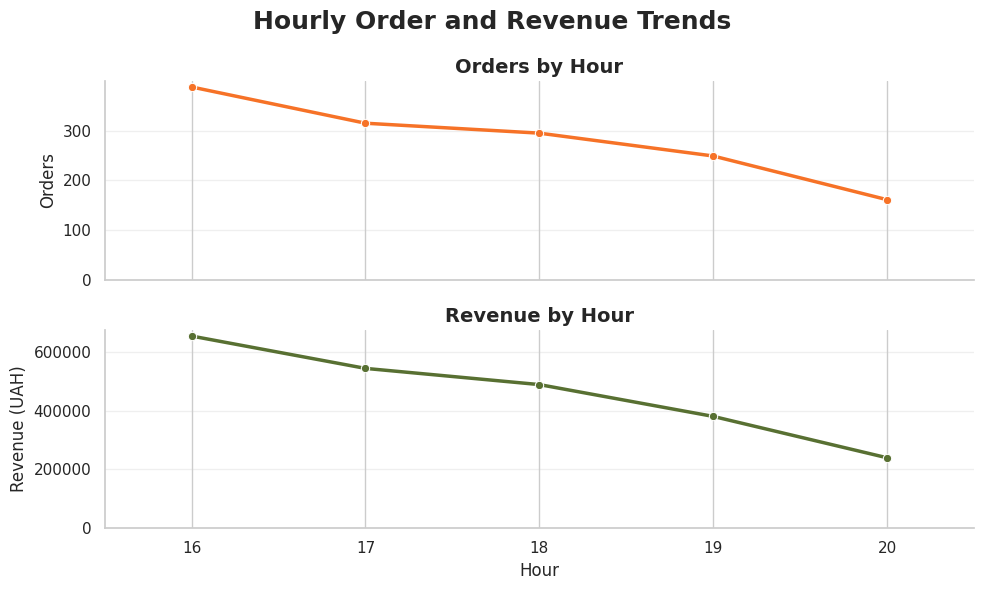

In [48]:
# Hourly performance dashboard

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

sns.lineplot(
    data=hourly_metrics,
    x="hour",
    y="orders",
    marker="o",
    linewidth=2.5,
    color=colors[1],
    ax=axes[0]
)

axes[0].set_title("Orders by Hour", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Orders")
axes[0].set_xlabel("")
axes[0].set_ylim(0)

sns.lineplot(
    data=hourly_metrics,
    x="hour",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color=colors[0],
    ax=axes[1]
)

axes[1].set_title("Revenue by Hour", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Revenue (UAH)")
axes[1].set_xlabel("Hour")
axes[1].set_ylim(0)

for ax in axes:
    ax.set_xlim(
        hourly_metrics["hour"].min() - 0.5,
        hourly_metrics["hour"].max() + 0.5
    )
    ax.set_xticks(hourly_metrics["hour"].unique())
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Hourly Order and Revenue Trends", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Hourly Performance Findings**

Customer activity is highest at **16:00**, when the restaurant records the largest number of orders (**388**) and the highest revenue (**654 thousand UAH**).

Both orders and revenue gradually decline throughout the evening. By **20:00**, order volume falls to **161 orders**, while revenue decreases to **240 thousand UAH**.

The average order value remains relatively stable during all operating hours, ranging from **1,490 UAH** to **1,727 UAH**. This suggests that changes in revenue are mainly driven by the number of orders rather than differences in customer spending.

Overall, the restaurant experiences its peak demand between **16:00 and 18:00**, making this period the most important for daily sales performance.

**Note:** The dataset contains orders placed between 16:00 and 20:00 only. This may reflect the restaurant's operating hours or the time window captured in the data.

**Revenue per Product**

In [49]:
# Revenue per product

category_efficiency = (
    category_metrics
    .merge(category_portfolio, on="category")
)

category_efficiency["revenue_per_product"] = (
    category_efficiency["revenue"] / category_efficiency["products_count"]
)

category_efficiency = category_efficiency.sort_values(
    "revenue_per_product",
    ascending=False
)

category_efficiency

,category,revenue,orders,quantity,revenue_share,avg_revenue_per_order,products_count,revenue_per_product
1,SOUPS,"586,969.47",637,1156,25.44,921.00,7,"83,852.78"
2,MAIN COURSES,"501,365.40",733,1052,21.73,684.00,8,"62,670.68"
0,EXTRAS,"768,766.25",1244,3530,33.32,618.00,18,"42,709.24"
3,APETISERS,"288,622.90",617,1028,12.51,468.00,13,"22,201.76"
5,SPECIAL ORDERS,"42,563.41",59,73,1.84,721.00,3,"14,187.80"
4,Restaurant DEALS,"77,341.93",45,47,3.35,"1,719.00",6,"12,890.32"
7,Friday Specials,"7,486.63",12,14,0.32,624.00,1,"7,486.63"
6,DRINKS,"34,241.63",206,257,1.48,166.00,7,"4,891.66"


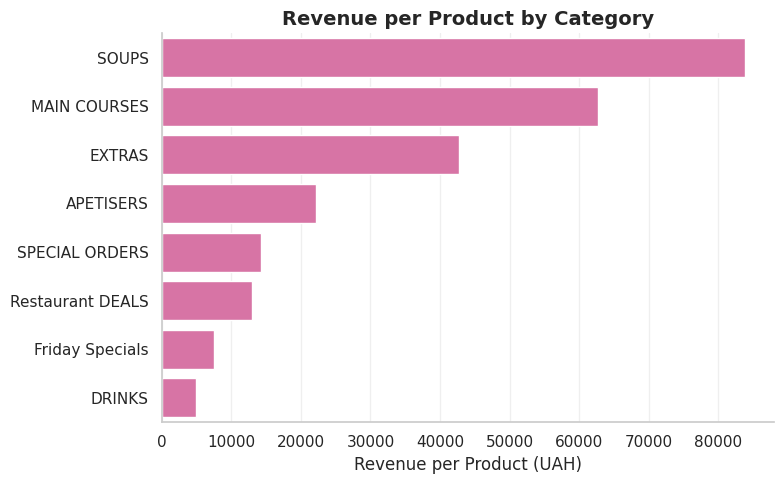

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_efficiency,
    x="revenue_per_product",
    y="category",
    color=colors[2]
)

plt.title(
    "Revenue per Product by Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Revenue per Product (UAH)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

**Revenue per Product Findings**

SOUPS generate the highest revenue per product (**83.9k UAH**), followed by MAIN COURSES (**62.7k UAH**). This indicates strong demand despite a relatively small number of menu items.

Although EXTRAS generates the highest total revenue, its revenue per product is lower (**42.7k UAH**) due to a much larger product portfolio.

APETISERS generate **22.2k UAH** per product, while DRINKS show the lowest result at **4.9k UAH**.

Overall, SOUPS and MAIN COURSES are the most efficient categories in terms of revenue generated per menu item.

### **6.8. Profitability Analysis**

In [51]:
profit_summary = pd.DataFrame({
    "Metric": ["Revenue", "Estimated Profit", "Profit Margin"],
    "Value": [
        f"{sales['gross_sales_uah'].sum():,.0f} UAH",
        f"{sales['est_profit_uah'].sum():,.0f} UAH",
        f"{sales['est_profit_uah'].sum() / sales['gross_sales_uah'].sum() * 100:.1f}%"
    ]
}).set_index("Metric")

display(profit_summary)

,Value
Metric,
Revenue,"2,307,358 UAH"
Estimated Profit,"1,500,154 UAH"
Profit Margin,65.0%


In [52]:
profit_by_year = (
    sales.groupby("year", as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        profit=("est_profit_uah", "sum")
    )
)
profit_by_year["profit_margin"] = (
    profit_by_year["profit"] / profit_by_year["revenue"] * 100
)

profit_by_year

,year,revenue,profit,profit_margin
0,2023,"1,139,473.61","740,843.22",65.02
1,2024,"704,041.23","457,713.30",65.01
2,2025,"463,842.79","301,597.73",65.02


In [53]:
category_profit = (
    sales.groupby("category", as_index=False)
    .agg(
        revenue=("gross_sales_uah", "sum"),
        profit=("est_profit_uah", "sum")
    )
)
category_profit["profit_margin"] = (
    category_profit["profit"] / category_profit["revenue"] * 100
).round(1)
category_profit = category_profit.sort_values("profit", ascending=False)

category_profit

,category,revenue,profit,profit_margin
2,EXTRAS,"768,766.25","499,817.37",65.00
6,SOUPS,"586,969.47","381,622.32",65.00
4,MAIN COURSES,"501,365.40","325,991.01",65.00
0,APETISERS,"288,622.90","187,667.97",65.00
5,Restaurant DEALS,"77,341.93","50,271.36",65.00
7,SPECIAL ORDERS,"42,563.41","27,667.71",65.00
1,DRINKS,"34,241.63","22,249.90",65.00
3,Friday Specials,"7,486.63","4,866.61",65.00


**Profitability Findings**

The restaurant generated approximately **2.31 million UAH** in revenue and **1.50 million UAH** in estimated profit during the analyzed period.

The estimated profit margin remained stable at around **65%**, indicating that profitability is primarily driven by sales volume rather than differences in product margins.

### **EDA Summary**

The exploratory analysis provided a comprehensive overview of the restaurant's performance between **2023 and 2025**.

The results revealed a significant decline in both **revenue** and **order volume** over time. While the **average order value increased**, overall business performance was negatively affected by decreasing customer demand and fewer transactions.

The menu analysis showed that revenue is highly concentrated in a small number of categories. **EXTRAS, SOUPS, and MAIN COURSES generate nearly 80% of total revenue**, making them the key drivers of restaurant performance.

At the product level, several flagship dishes account for a large share of category revenue and orders, particularly within the **SOUPS** category. At the same time, **EXTRAS demonstrates a more diversified product portfolio with lower concentration risk**.

Customer behavior analysis showed that most orders contain **3-6 items**, with an average order value of approximately **1,639 UAH**. Demand remains relatively stable throughout the week, with **Saturday generating the highest revenue and order volume**. The strongest sales period occurs between **16:00 and 18:00**.

Operational analysis highlighted that **SOUPS and MAIN COURSES are the most efficient categories** in terms of revenue generated per menu item, while **DRINKS contribute relatively little to overall business performance**.

**Key Takeaways**

- Revenue and order volume have **declined significantly** since 2023.
- **EXTRAS, SOUPS, and MAIN COURSES** generate almost **80% of total revenue**.
- **SOUPS** is the most efficient category based on revenue per product.
- Most customers purchase **3-6 items per order** with an average spend of **1,639 UAH**.
- **Saturday** is the strongest day of the week, while **16:00-18:00** is the peak sales period.
- The business relies heavily on a small number of categories and flagship products.
- The main challenge is **declining customer demand**, not pricing or profitability.

## **7. Delivery Channel Analysis**

This section analyzes revenue performance across three digital sales channels: JustEat, Deliveroo, and the restaurant's own website. Channel revenue was converted from GBP to UAH using the same exchange rate applied throughout this analysis.
  

In [54]:
# Channel dataset preparation

channels.columns = (
    channels.columns
    .str.strip()
    .str.lower()
)

channels["year"] = channels["financial_year"].str[:4].astype(int)

channels["period"] = pd.to_datetime(
    dict(
        year=channels["year"],
        month=channels["month_num"],
        day=1
    )
)

channels["revenue_uah"] = channels["revenue"] * GBP_TO_UAH
channels["revenue_k_uah"] = channels["revenue_uah"] / 1_000

channels.head()

,financial_year,month_num,month,channel,revenue,revenue_source,year,period,revenue_uah,revenue_k_uah
0,2022-23,1,January,Deliveroo,324.36,Observed,2022,2022-01-01,"19,349.50",19.35
1,2022-23,1,January,JustEat,"1,827.50",Observed,2022,2022-01-01,"109,018.42",109.02
2,2022-23,1,January,Website,"1,934.75",Observed,2022,2022-01-01,"115,416.35",115.42
3,2022-23,2,February,Deliveroo,673.20,Observed,2022,2022-02-01,"40,159.34",40.16
4,2022-23,2,February,JustEat,"2,129.00",Observed,2022,2022-02-01,"127,004.22",127.00


In [55]:
# Channel summary

channel_summary = (
    channels.groupby("channel", as_index=False)
    .agg(
        revenue=("revenue_uah", "sum")
    )
    .sort_values("revenue", ascending=False)
)

channel_summary["revenue_share"] = (
    channel_summary["revenue"] / channel_summary["revenue"].sum() * 100
).round(1)

channel_summary

,channel,revenue,revenue_share
1,JustEat,"3,779,255.97",48.20
2,Website,"2,307,357.62",29.50
0,Deliveroo,"1,747,299.45",22.30


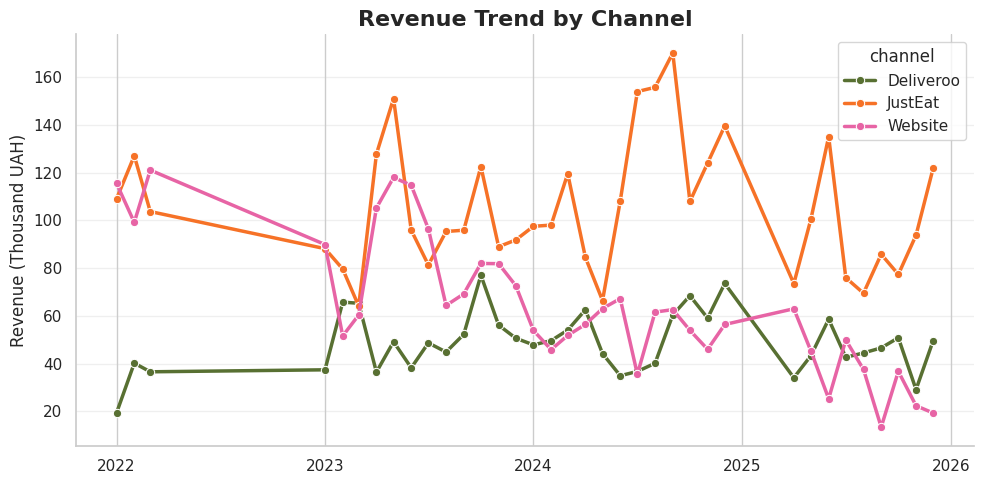

In [56]:
# Revenue trend by channel

channel_palette = {
    "Deliveroo": colors[0],
    "JustEat": colors[1],
    "Website": colors[2]
}

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=channels,
    x="period",
    y="revenue_k_uah",
    hue="channel",
    palette=channel_palette,
    marker="o",
    linewidth=2.5
)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Revenue Trend by Channel", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Revenue (Thousand UAH)")

plt.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

In [57]:
# Channel revenue by financial year

channel_yearly = (
    channels.groupby(["financial_year", "channel"], as_index=False)
    .agg(
        revenue=("revenue_uah", "sum")
    )
)

channel_yearly_pivot = channel_yearly.pivot_table(
    index="financial_year",
    columns="channel",
    values="revenue",
    aggfunc="sum"
)

channel_yearly_pivot

channel,Deliveroo,JustEat,Website
financial_year,,,
2022-23,"96,035.23","339,672.15","335,541.09"
2023-24,"621,319.07","1,181,771.56","1,005,624.05"
2024-25,"631,018.28","1,424,748.11","653,752.57"
2025-26,"398,926.87","833,064.15","312,439.92"


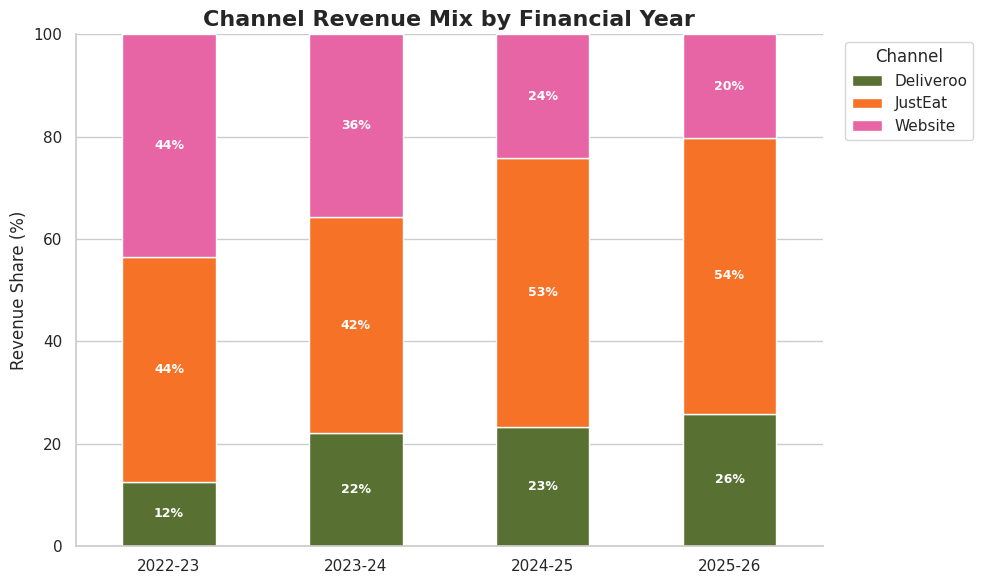

In [58]:
# Channel revenue mix by financial year

channel_mix_pivot = (
    channel_yearly_pivot
    .div(channel_yearly_pivot.sum(axis=1), axis=0)
    .mul(100)
)

ax = channel_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[colors[0], colors[1], colors[2]]
)

for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 8 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

plt.title("Channel Revenue Mix by Financial Year", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Revenue Share (%)")
plt.ylim(0, 100)

# Форматування xticks
ax.set_xticks(range(len(channel_mix_pivot.index)))
ax.set_xticklabels(
    [str(label) for label in channel_mix_pivot.index],
    rotation=0
)

plt.legend(
    title="Channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()
plt.show()

**Channel Analysis Findings**

The restaurant generates digital revenue through three channels: **JustEat**, **Website**, and **Deliveroo**.

For consistency with the main sales analysis, channel revenue was converted from GBP to UAH using the same exchange rate.

**JustEat** is the largest channel, contributing nearly **48% of total channel revenue**. Its share increased over time, making it the restaurant's main digital sales driver.

The **Website** is the second-largest channel, but its revenue declined after **2023-24**. This suggests weaker direct online sales and growing dependence on external platforms.

**Deliveroo** remains the smallest channel, contributing around **22% of total revenue**, but its share stayed relatively stable across most years.

Overall, the restaurant became more dependent on third-party delivery platforms, especially **JustEat**, while direct Website sales lost importance over time.

## **8. Deliveroo Category Analysis**

Deliveroo operates as a separate delivery platform with its own category structure, which differs from the internal restaurant menu classification. The following analysis examines category performance specifically within the Deliveroo platform.

In [59]:
# Deliveroo dataset preparation

deliver_cat.columns = (
    deliver_cat.columns
    .str.strip()
    .str.lower()
    .str.replace("ï»¿", "")
)

deliver_cat["gross_revenue_uah"] = deliver_cat["gross_revenue"] * GBP_TO_UAH
deliver_cat["gross_revenue_k_uah"] = deliver_cat["gross_revenue_uah"] / 1_000

In [60]:
# Deliveroo category summary

deliveroo_category = (
    deliver_cat.groupby("category", as_index=False)
    .agg(
        revenue=("gross_revenue_uah", "sum"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

deliveroo_category["revenue_share"] = (
    deliveroo_category["revenue"] / deliveroo_category["revenue"].sum() * 100
).round(2)

deliveroo_category

,category,revenue,quantity,revenue_share
3,Main Courses,"559,319.65",1162,31.86
2,Extras,"361,744.28",1648,20.60
0,Appetisers,"315,113.63",1046,17.95
7,Soups,"288,035.30",598,16.41
4,Modifiers,"78,743.81",999,4.48
6,Solids,"74,538.17",327,4.25
1,Drinks,"43,368.75",410,2.47
5,Promotional Bundles,"34,897.82",21,1.99


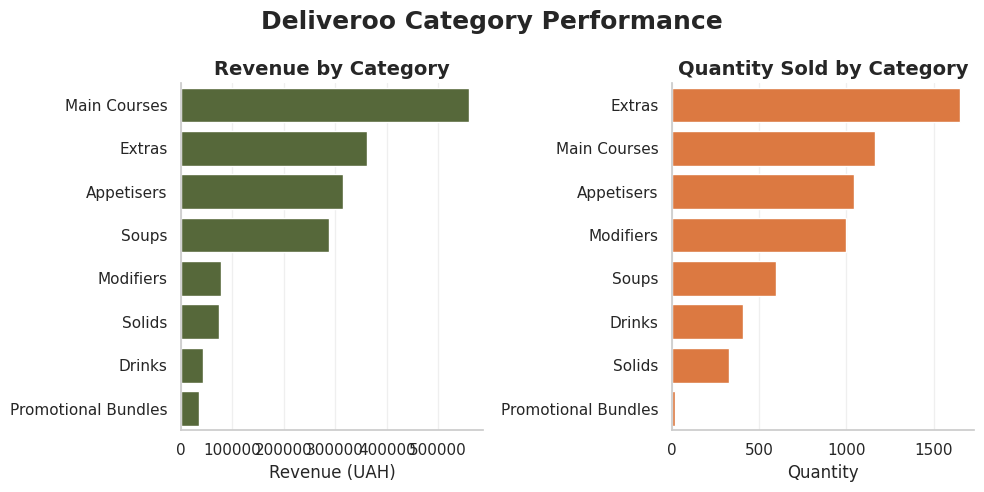

In [61]:
# Deliveroo category performance dashboard

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(
    data=deliveroo_category,
    x="revenue",
    y="category",
    color=colors[0],
    ax=axes[0]
)

axes[0].set_title("Revenue by Category", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Revenue (UAH)")
axes[0].set_ylabel("")

sns.barplot(
    data=deliveroo_category.sort_values("quantity", ascending=False),
    x="quantity",
    y="category",
    color=colors[1],
    ax=axes[1]
)

axes[1].set_title("Quantity Sold by Category", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("")

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Deliveroo Category Performance", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Deliveroo Category Performance Findings**

**Main Courses** is the largest category on Deliveroo, generating **31.9% of total revenue** and selling more than **1,100 items**. It is the main driver of delivery sales.

**Extras** has the highest sales volume with **1,648 items sold**, but contributes only **20.6% of revenue**. This suggests that customers frequently add these items to their orders, although their average value is relatively low.

**Appetisers** and **Soups** are also important categories, together generating more than **34% of total revenue**.

**Soups** appear particularly efficient, producing a relatively large share of revenue compared to the number of items sold.

**Drinks**, **Solids**, and **Promotional Bundles** contribute only a small share of overall delivery revenue.

Overall, Deliveroo sales are concentrated in four key categories: **Main Courses, Extras, Appetisers, and Soups**, which together account for almost **87% of total revenue**.

In [62]:
# Deliveroo revenue growth by category

deliveroo_yearly = (
    deliver_cat.groupby(["year", "category"], as_index=False)
    .agg(
        revenue=("gross_revenue_uah", "sum")
    )
    .pivot_table(
        index="category",
        columns="year",
        values="revenue",
        aggfunc="sum"
    )
)

deliveroo_yearly["growth_pct"] = (
    (deliveroo_yearly[2025] - deliveroo_yearly[2023])
    / deliveroo_yearly[2023]
    * 100
)

deliveroo_growth = deliveroo_yearly.sort_values("growth_pct", ascending=False)

deliveroo_growth

year,2023,2024,2025,growth_pct
category,,,,
Promotional Bundles,"3,280.99","3,280.99","28,335.84",763.64
Appetisers,"57,059.43","115,669.88","142,384.32",149.54
Solids,"15,897.90","24,786.40","33,853.87",112.95
Drinks,"8,172.65","21,833.51","13,362.59",63.50
Soups,"71,764.24","100,547.49","115,723.57",61.26
Extras,"87,721.80","138,099.94","135,922.55",54.95
Main Courses,"163,960.12","255,499.80","139,859.74",-14.70
Modifiers,"29,349.96","37,313.83","12,080.02",-58.84


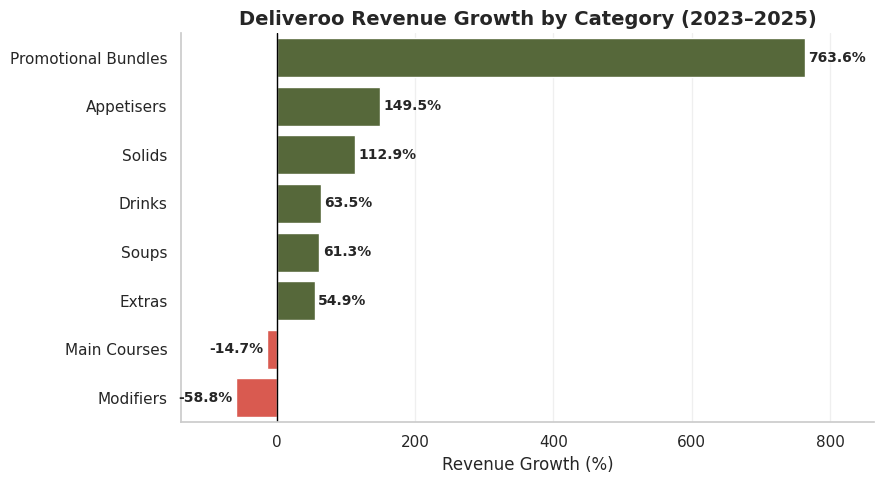

In [63]:
# Deliveroo revenue growth chart

growth_plot = deliveroo_growth.reset_index()

growth_plot["bar_color"] = np.where(
    growth_plot["growth_pct"] >= 0,
    colors[0],
    colors[4]
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=growth_plot,
    x="growth_pct",
    y="category",
    hue="category",
    palette=dict(zip(growth_plot["category"], growth_plot["bar_color"])),
    legend=False,
    ax=ax
)

ax.axvline(0, color="black", linewidth=1)

for i, row in growth_plot.iterrows():
    val = row["growth_pct"]
    x = val + 5 if val >= 0 else val - 5
    ha = "left" if val >= 0 else "right"
    ax.text(
        x, i, f"{val:.1f}%",
        va="center", ha=ha,
        fontsize=10, fontweight="bold"
    )

ax.set_xlim(
    growth_plot["growth_pct"].min() - 80,
    growth_plot["growth_pct"].max() + 100
)

ax.set_title(
    "Deliveroo Revenue Growth by Category (2023–2025)",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Revenue Growth (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

**Deliveroo Growth Findings**

Most Deliveroo categories increased their revenue between **2023 and 2025**.

- **Appetisers (+150%)**, **Solids (+113%)**, **Soups (+61%)**, and **Extras (+55%)** recorded the strongest growth, indicating increasing customer demand on the platform.

- **Promotional Bundles (+764%)** showed the highest growth rate. However, this result should be interpreted with caution because the category started from a very low revenue base. Small absolute increases can therefore produce very large percentage changes.

- **Main Courses (-15%)** and **Modifiers (-59%)** experienced revenue declines, suggesting changing customer preferences within these categories.

Overall, Deliveroo growth was concentrated in a few categories rather than being evenly distributed across the menu.

In [64]:
# Deliveroo vs restaurant category mix

mix_comparison = (
    category_metrics[
        ["category", "revenue_share"]
    ]
    .assign(
        category=lambda df: df["category"].replace({
            "APETISERS": "Appetisers",
            "DRINKS": "Drinks",
            "EXTRAS": "Extras",
            "MAIN COURSES": "Main Courses",
            "SOUPS": "Soups"
        })
    )
    .query(
        "category in ['Appetisers', 'Drinks', 'Extras', 'Main Courses', 'Soups']"
    )
    .merge(
        deliveroo_category[
            ["category", "revenue_share"]
        ],
        on="category",
        suffixes=(
            "_restaurant",
            "_deliveroo"
        )
    )
)


In [65]:
# Difference between Deliveroo and restaurant mix

mix_comparison["difference"] = (
    mix_comparison["revenue_share_deliveroo"]
    - mix_comparison["revenue_share_restaurant"]
)

mix_comparison = mix_comparison.sort_values(
    "difference",
    ascending=False
)

mix_comparison

,category,revenue_share_restaurant,revenue_share_deliveroo,difference
2,Main Courses,21.73,31.86,10.13
3,Appetisers,12.51,17.95,5.44
4,Drinks,1.48,2.47,0.99
1,Soups,25.44,16.41,-9.03
0,Extras,33.32,20.60,-12.72


In [66]:
# Prepare data for chart

comparison_plot = (
    mix_comparison.melt(
        id_vars="category",
        value_vars=[
            "revenue_share_restaurant",
            "revenue_share_deliveroo"
        ],
        var_name="source",
        value_name="share"
    )
)

comparison_plot["source"] = (
    comparison_plot["source"]
    .replace({
        "revenue_share_restaurant": "Restaurant",
        "revenue_share_deliveroo": "Deliveroo"
    })
)

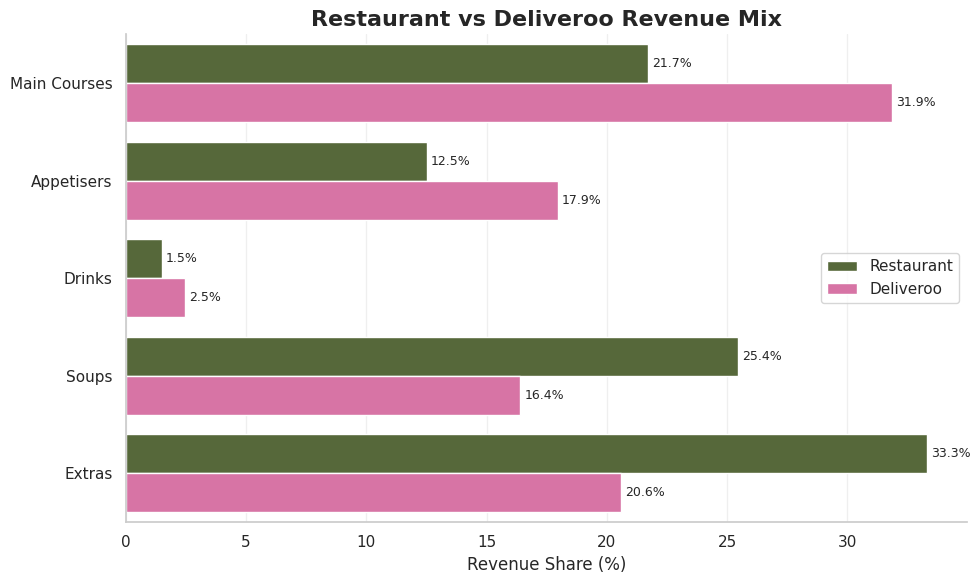

In [67]:
# Restaurant vs Deliveroo revenue mix

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=comparison_plot,
    x="share",
    y="category",
    hue="source",
    palette=[colors[0], colors[2]]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title("Restaurant vs Deliveroo Revenue Mix", fontsize=16, fontweight="bold")
plt.xlabel("Revenue Share (%)")
plt.ylabel("")

plt.legend(title="")
plt.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

**Restaurant vs Deliveroo Revenue Mix Findings**

The category mix differs between Deliveroo and overall restaurant sales.

**Main Courses** and **Appetisers** have a larger revenue share on Deliveroo, suggesting that delivery customers mainly order complete meals and starter items.

In contrast, **Extras** and **Soups** contribute a larger share of restaurant revenue, indicating stronger demand for add-ons and complementary dishes in direct orders.

Overall, Deliveroo sales are more focused on core meal categories, while restaurant sales are more diversified across the menu.

## **9. Financial Overview**

### **9.1. Revenue Structure**

In [68]:
# Revenue structure

pnl.columns = (
    pnl.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(£)", "gbp", regex=False)
)

revenue_sources = (
    pnl[pnl["account_category"] == "Operating Revenue"]
    .assign(
        value_uah=lambda df: df["value_gbp"] * GBP_TO_UAH,
        revenue_share=lambda df: (
            df["value_gbp"] / df["value_gbp"].sum() * 100
        ).round(1)
    )
    [["description", "value_uah", "revenue_share"]]
    .sort_values("revenue_share", ascending=False)
)

revenue_sources

,description,value_uah,revenue_share
6,Legacy Period Reconciliation,"4,285,348.99",25.00
2,In-Store Point of Sale (POS),"4,083,148.61",23.80
3,Third-Party Delivery Platform A,"3,779,255.97",22.00
4,Third-Party Delivery Platform B,"1,747,299.45",10.20
0,Direct Web Sales (Processor A),"1,364,788.28",8.00
1,Direct Web Sales (Processor B),"942,569.35",5.50
5,Corporate Catering/BACS,"943,732.61",5.50


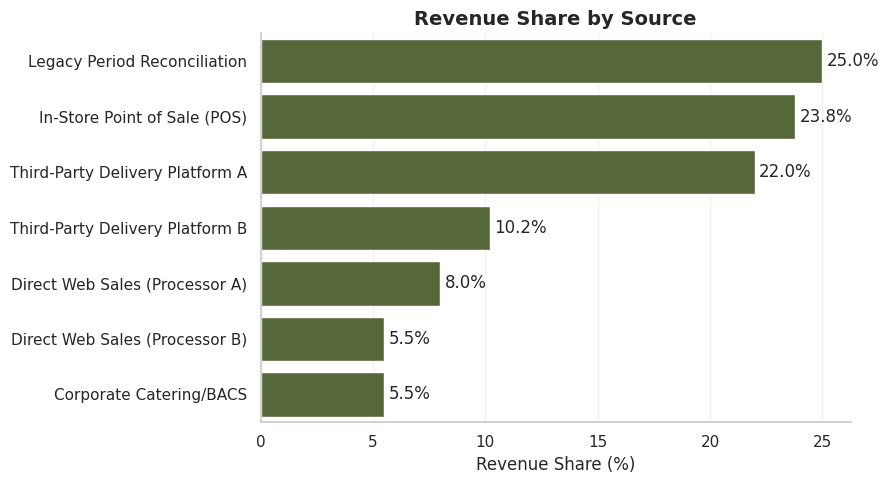

In [69]:
# Revenue share by source

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=revenue_sources,
    x="revenue_share",
    y="description",
    color=colors[0]
)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)

plt.title("Revenue Share by Source", fontsize=14, fontweight="bold")
plt.xlabel("Revenue Share (%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

**Revenue Structure Findings**

The largest reported revenue component is **Legacy Period Reconciliation**, accounting for **25.0% of total revenue**. As this is an accounting adjustment, it should not be treated as a regular sales channel.

Among operating revenue sources, **In-Store POS** is the largest contributor (**23.8%**), followed by **Third-Party Delivery Platform A** (**22.0%**).

Delivery platforms together generate more than **32% of total revenue**, highlighting the importance of external delivery partners.

Direct web sales contribute approximately **13.5%**, while corporate catering accounts for **5.5%** of revenue.

Overall, revenue is diversified across multiple channels, with in-store and delivery sales acting as the primary business drivers.

### **9.2. Cost Structure**


In [70]:
# Cost breakdown

cost_labels = {
    "Staffing & Labour Costs (Payroll/Transfers)": "Labour",
    "Cost of Sales (Raw Materials/Stock)": "Raw Materials",
    "Property Rent & Statutory Rates": "Rent",
    "Utilities (Energy/Water/Waste)": "Utilities",
    "Platform Commissions (Commission-based)": "Commissions",
    "Strategic Management & Consulting": "Management",
    "Maintenance & Technical Support": "Maintenance",
    "Packaging & Service Consumables": "Packaging",
    "Insurance & Professional Indemnity": "Insurance",
    "Accountancy & Regulatory Filings": "Accounting",
    "Software & Digital Infrastructure": "Software",
    "Marketing & Business Development": "Marketing",
    "Merchant Processing Fees (Transactional)": "Processing Fees"
}

cost_breakdown = (
    pnl[pnl["account_category"].isin([
        "Variable Costs (COGS)",
        "Operating Expenses (Fixed)",
        "Administrative Expenses"
    ])]
    .assign(
        value_uah=lambda df: df["value_gbp"].abs() * GBP_TO_UAH,
        short_desc=lambda df: df["description"].replace(cost_labels)
    )
    [["short_desc", "value_uah"]]
    .sort_values("value_uah", ascending=False)
)

cost_breakdown["cost_share"] = (
    cost_breakdown["value_uah"]
    / cost_breakdown["value_uah"].sum()
    * 100
).round(1)

cost_breakdown

,short_desc,value_uah,cost_share
17,Labour,"4,676,904.96",31.60
9,Raw Materials,"2,878,324.80",19.40
18,Rent,"2,863,411.20",19.30
19,Utilities,"1,494,366.58",10.10
10,Commissions,"773,717.57",5.20
25,Management,"536,889.60",3.60
20,Maintenance,"477,831.74",3.20
12,Packaging,"268,444.80",1.80
26,Insurance,"241,600.32",1.60
27,Accounting,"205,807.68",1.40


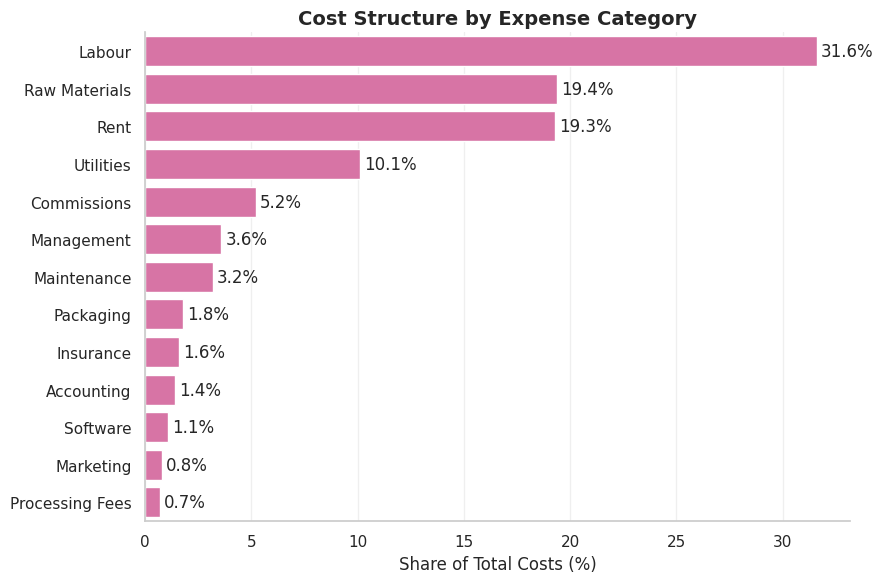

In [71]:
# Top cost drivers

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=cost_breakdown,
    x="cost_share",
    y="short_desc",
    color=colors[2]
)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.title("Cost Structure by Expense Category", fontsize=14, fontweight="bold")
plt.xlabel("Share of Total Costs (%)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

**Cost Structure Findings**

**Labour** is the largest cost driver, representing **31.6% of total costs**.

**Raw Materials** (**19.4%**) and **Rent** (**19.3%**) are the next largest expenses, followed by **Utilities** (**10.1%**).

Together, labour, raw materials, rent, and utilities account for approximately **80% of all business expenses**, making them the key areas influencing profitability.

The remaining cost categories each contribute less than **6%** of total costs.

### **9.3. Profitability Overview**

In [72]:
# Profitability waterfall data

profitability_waterfall = pd.DataFrame({
    "stage": [
        "Revenue",
        "COGS",
        "Gross Profit",
        "Operating Expenses",
        "Administrative Expenses",
        "Net Profit"
    ],
    "value": [
        pnl.loc[pnl["account_category"] == "Total Operating Revenue", "value_gbp"].iloc[0] * GBP_TO_UAH,
        pnl.loc[pnl["account_category"] == "Total Variable Costs (COGS)", "value_gbp"].iloc[0] * GBP_TO_UAH,
        pnl.loc[pnl["account_category"] == "GROSS PROFIT", "value_gbp"].iloc[0] * GBP_TO_UAH,
        pnl.loc[pnl["account_category"] == "Total Operating Expenses (Fixed)", "value_gbp"].iloc[0] * GBP_TO_UAH,
        pnl.loc[pnl["account_category"] == "Total Administrative Expenses", "value_gbp"].iloc[0] * GBP_TO_UAH,
        pnl.loc[pnl["account_category"] == "NET PROFIT (EBIT)", "value_gbp"].iloc[0] * GBP_TO_UAH
    ]
})

profitability_waterfall

,stage,value
0,Revenue,"17,146,143.25"
1,COGS,"-4,028,909.04"
2,Gross Profit,"13,117,234.21"
3,Operating Expenses,"-9,807,207.22"
4,Administrative Expenses,"-984,297.60"
5,Net Profit,"2,325,729.39"


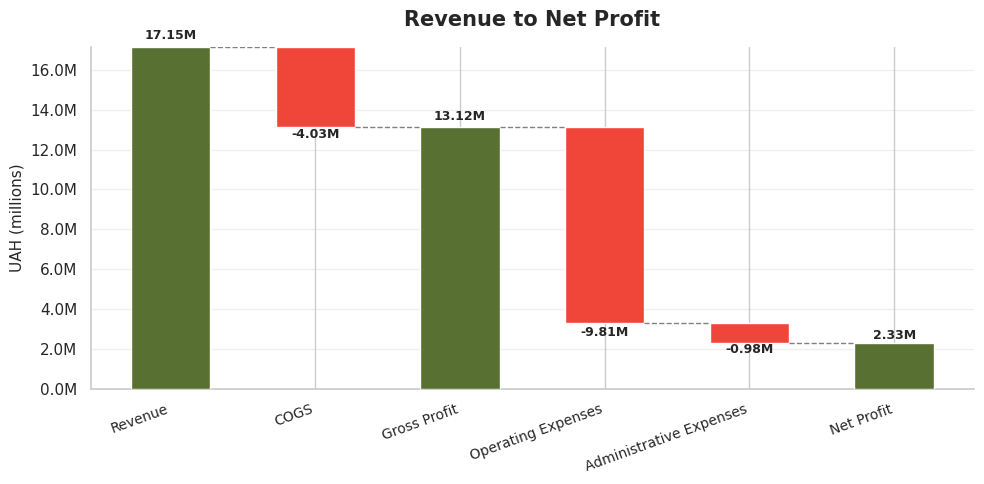

In [73]:
vals = profitability_waterfall["value"].values
stages = profitability_waterfall["stage"].values

bottoms = []
running = 0
for i, (stage, val) in enumerate(zip(stages, vals)):
    if stage in ["Revenue", "Gross Profit", "Net Profit"]:
        bottoms.append(0)
        running = val
    else:
        bottoms.append(running)
        running += val

bar_colors = [colors[0] if v > 0 else colors[4] for v in vals]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    range(len(stages)),
    vals,
    bottom=bottoms,
    color=bar_colors,
    width=0.55,
    zorder=3
)

tops = [b + v for b, v in zip(bottoms, vals)]

for i in range(len(stages) - 1):
    ax.plot(
        [i + 0.275, i + 0.725],
        [tops[i], tops[i]],
        color="grey",
        linewidth=1,
        linestyle="--",
        zorder=4
    )

for i, (val, bottom) in enumerate(zip(vals, bottoms)):
    top = bottom + val
    label = f"{val/1_000_000:+.2f}M" if stages[i] not in ["Revenue", "Gross Profit", "Net Profit"] else f"{val/1_000_000:.2f}M"
    va = "bottom" if val >= 0 else "top"
    offset = abs(val) * 0.015
    y_pos = top + offset if val >= 0 else top - offset
    ax.text(i, y_pos, label, ha="center", va=va, fontsize=9, fontweight="bold")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("UAH (millions)", fontsize=11)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Revenue to Net Profit", fontsize=15, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3, zorder=0)

sns.despine()
plt.tight_layout()
plt.show()

**Profitability Findings**

The restaurant generated **17.15M UAH** in revenue and **13.12M UAH** in gross profit, resulting in a strong **gross margin of 76.5%**.

However, operating expenses reduced profitability significantly. Fixed operating costs alone amounted to **9.81M UAH**, representing the largest reduction between gross profit and net profit.

After all expenses, the business achieved a **net profit of 2.33M UAH**, corresponding to a **net margin of 13.6%**.

Overall, the business remains profitable, but profitability is influenced more by operating expenses than by product costs.

**Note:** The P&L dataset reflects the full consolidated revenue of the restaurant across all channels and periods, while the sales dataset represents transaction-level records from a single operational source. The difference in scale reflects this distinction and should be considered when comparing figures across sections.

## **10. Key Insights**

**1. Revenue is concentrated in a few categories and products**

EXTRAS, SOUPS, and MAIN COURSES generate more than 80% of total revenue. Within SOUPS, just three dishes account for 86% of category revenue, with Efo Riro alone responsible for 45% - making it the restaurant's single most important product.

**2. Customer demand declined significantly**

Order volume fell from 733 orders in 2023 to 242 orders in 2025 - a decline of approximately 67%. Revenue dropped from 1.14M UAH to 0.46M UAH over the same period. The average order value, however, increased from 1,555 UAH to 1,917 UAH, indicating that remaining customers spend more per transaction.

**3. Restaurant DEALS is underutilised**

This category has the highest average order value of any category (1,719 UAH) but recorded only 45 orders across the entire period - a clear gap between value per order and actual demand.

**4. Delivery platforms dominate digital revenue**

JustEat is the largest digital channel, accounting for 48% of channel revenue. Its share increased from 44% in FY2022-23 to 54% in FY2025-26. Over the same period, Website revenue share declined from 44% to 20%, showing increasing dependence on third-party platforms.

**5. Delivery and direct customers order differently**

Deliveroo customers favour Main Courses and Appetisers, while direct customers generate a larger share from Extras and Soups - delivery customers prefer complete meals, direct customers build more customised orders.

**6. Demand is concentrated in time and day**

Saturday is the strongest trading day (594k UAH, 343 orders), and 16:00-18:00 is the peak sales window. Sunday is absent from the dataset, suggesting no current Sunday service.

**7. The business remains profitable despite declining demand**

Despite the 67% drop in order volume, profit margin held steady at approximately 65%. The consolidated P&L shows a gross margin of 76.5% and a net margin of 13.6%, with labour, raw materials, and rent driving roughly 70% of total costs.

## **11. Business Recommendations**

**1. Protect and promote core revenue drivers**

Prioritize SOUPS, MAIN COURSES, and EXTRAS, and feature Efo Riro as a signature dish across menus and delivery platforms - it is the restaurant's strongest single product.

**2. Unlock Restaurant DEALS**

With the highest average order value and a format naturally suited to group dining, targeted promotion of sharing packs and pre-orders could grow revenue without requiring more orders overall.

**3. Strengthen direct sales channels**

Invest in the website and direct ordering to reverse its declining share (44% - 20%) and reduce dependency on third-party commission fees.

**4. Adapt platform strategy to customer behaviour**

Highlight complete meals on Deliveroo, and promote extras and soups through direct channels, matching each platform to how its customers actually order.

**5. Leverage peak periods and explore Sunday trading**

Maximize capacity and promotions around Saturday and 16:00-18:00. Given Saturday's strength, introducing even limited Sunday service could add incremental revenue.

**6. Control core operating costs**

Labour, raw materials, and rent drive ~70% of costs. Regular review of staffing against peak hours and supplier terms will help protect margins as revenue fluctuates.

## **Final Conclusion**

This analysis examined the **operational and financial performance** of an independent West African restaurant between **2023 and 2025**, covering sales trends, product and category performance, customer behavior, delivery channels, and consolidated financials.

The business faces a clear structural challenge: order volume declined by **67%** over three years, driven by *falling customer demand* rather than pricing or profitability issues. Despite this, the restaurant demonstrated strong operational resilience - maintaining a consistent profit margin of approximately **65%** across all categories and years, and achieving a consolidated **net margin of 13.6%**.

Revenue is highly concentrated in three categories and a small number of flagship products, with ***Efo Riro*** standing out as the single most important dish. This concentration drives efficiency but also creates risk if demand for key items changes.

Delivery platforms, particularly **JustEat**, have become the dominant revenue channel, while direct website sales have declined significantly. Customer preferences differ between channels, with delivery customers favouring *complete meals* and direct customers building larger, more *customised orders*.

**Restaurant DEALS** remains the most underutilised opportunity in the business. With the highest average order value and a product format naturally suited to group dining and celebrations, targeted promotion of this category represents *one of the clearest paths to revenue growth* without requiring a significant increase in order volume.

To sustain and grow the business, the primary focus should be on recovering customer demand through **marketing investment**, **direct channel development**, and **extended trading hours**. At the same time, *protecting the core product portfolio*, *adapting platform strategies*, and *controlling operational costs* will be essential for long-term profitability.

The restaurant has a **strong product foundation**, a *loyal customer base*, and proven profitability. With targeted action on demand generation and channel diversification, it is well-positioned to **stabilize and grow**.